# Clustering

In [1]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt
import matplotlib

# Data pre-processing

In [34]:
df = pd.read_parquet("history.parquet")

# Remove all rows for Mogadishu
df = df[df['capital'] != 'Mogadishu']

# Add season column based on month
def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Autumn'

def get_decade(year):
    if 1995 <= year <= 2004:
        return '1995-2004'
    elif 2005 <= year <= 2014:
        return '2005-2014'
    elif 2015 <= year <= 2024:
        return '2015-2024'
    else:
        return 'Unknown'
    
def get_group(year):
    if year <= 2009:
        return 1
    else:
        return 2



df['date'] = pd.to_datetime(df['date'])

df['season'] = df['date'].dt.month.apply(get_season)
df['temp_variation'] = df['temp_max_c'] - df['temp_min_c']
df['year'] = df['date'].dt.year
df['decade'] = df['year'].apply(get_decade)
df['group'] = df['year'].apply(get_group)

#We'll need it later
capital_to_country = df[['capital', 'country']].drop_duplicates().set_index('capital')['country'].to_dict()
#Columns to drop

columns_to_keep = ['temp_mean_c_approx', 'rain_mm', 'snow_mm', 'windspeed_10m_max_kmh', 'temp_variation', 'sunshine_duration_s', 'daylight_duration_s', 'capital', 'year', 'season', 'date', 'decade', 'group']
df = df[columns_to_keep]

In [49]:
# PCA analysis on all columns
df = pd.read_parquet("history.parquet")

# Remove all rows for Mogadishu
df = df[df['capital'] != 'Mogadishu']

# Add season column based on month
def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Autumn'

def get_decade(year):
    if 1995 <= year <= 2004:
        return '1995-2004'
    elif 2005 <= year <= 2014:
        return '2005-2014'
    elif 2015 <= year <= 2024:
        return '2015-2024'
    else:
        return 'Unknown'
    
def get_group(year):
    if year <= 2009:
        return 1
    else:
        return 2



df['date'] = pd.to_datetime(df['date'])

df['season'] = df['date'].dt.month.apply(get_season)
df['temp_variation'] = df['temp_max_c'] - df['temp_min_c']
df['year'] = df['date'].dt.year
df['decade'] = df['year'].apply(get_decade)
df['group'] = df['year'].apply(get_group)

#We'll need it later
capital_to_country = df[['capital', 'country']].drop_duplicates().set_index('capital')['country'].to_dict()

#Columns to drop

Colonne numeriche trovate: ['lat', 'lon', 'temp_min_c', 'temp_max_c', 'temp_mean_c_approx', 'app_temp_min_c', 'app_temp_max_c', 'precip_mm', 'rain_mm', 'snow_mm', 'windspeed_10m_max_kmh', 'windgusts_10m_max_kmh', 'wind_dir_dom_deg', 'sunshine_duration_s', 'daylight_duration_s', 'shortwave_radiation_MJ_m2', 'temp_variation', 'year', 'group']


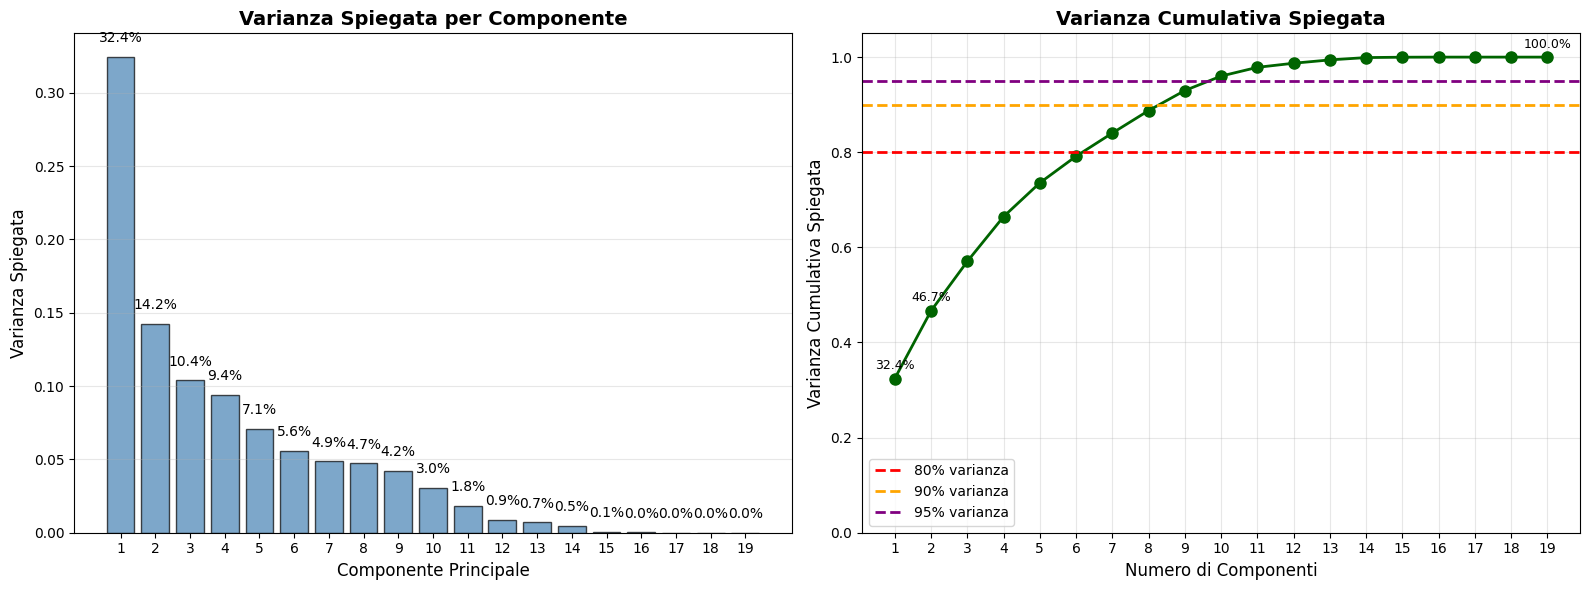

ANALISI PCA - VARIANZA SPIEGATA

Numero totale di features numeriche: 19

Varianza spiegata per componente:
  PC1: 32.43%
  PC2: 14.23%
  PC3: 10.39%
  PC4: 9.42%
  PC5: 7.10%
  PC6: 5.60%
  PC7: 4.87%
  PC8: 4.73%
  PC9: 4.21%
  PC10: 3.04%
  PC11: 1.84%
  PC12: 0.86%
  PC13: 0.70%
  PC14: 0.49%
  PC15: 0.08%
  PC16: 0.02%
  PC17: 0.00%
  PC18: 0.00%
  PC19: 0.00%


Varianza cumulativa:
  1 componente/i: 32.43%
  2 componente/i: 46.65%
  3 componente/i: 57.04%
  4 componente/i: 66.46%
  5 componente/i: 73.56%
  6 componente/i: 79.15%
  7 componente/i: 84.03%
  8 componente/i: 88.76%
  9 componente/i: 92.97%
  10 componente/i: 96.01%
  11 componente/i: 97.85%
  12 componente/i: 98.71%
  13 componente/i: 99.41%
  14 componente/i: 99.90%
  15 componente/i: 99.98%
  16 componente/i: 100.00%
  17 componente/i: 100.00%
  18 componente/i: 100.00%
  19 componente/i: 100.00%


Componenti necessarie per raggiungere:
  80% della varianza: 7 componenti (84.03%)
  90% della varianza: 9 componenti 

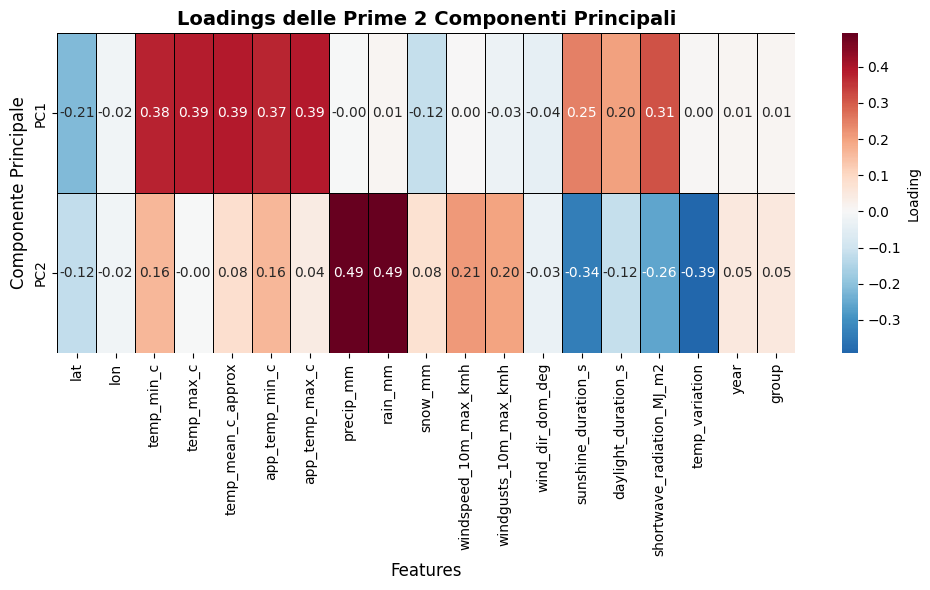

In [53]:
from sklearn.decomposition import PCA

# Select only numerical columns
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print(f"Colonne numeriche trovate: {numerical_cols}")

# Prepare data for PCA
df_numeric = df[numerical_cols].copy()

# Remove any rows with missing values
df_numeric = df_numeric.dropna()

# Scale the data
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_numeric)

# Perform PCA with all components
pca_full = PCA()
pca_full.fit(df_scaled)

# Calculate cumulative variance explained
cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)

# Create visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Variance explained by each component
axes[0].bar(range(1, len(pca_full.explained_variance_ratio_) + 1), 
            pca_full.explained_variance_ratio_, 
            alpha=0.7, 
            edgecolor='black',
            color='steelblue')
axes[0].set_xlabel('Componente Principale', fontsize=12)
axes[0].set_ylabel('Varianza Spiegata', fontsize=12)
axes[0].set_title('Varianza Spiegata per Componente', fontsize=14, fontweight='bold')
axes[0].set_xticks(range(1, len(pca_full.explained_variance_ratio_) + 1))
axes[0].grid(True, alpha=0.3, axis='y')

# Add percentage labels on bars
for i, var in enumerate(pca_full.explained_variance_ratio_):
    axes[0].text(i + 1, var + 0.01, f'{var:.1%}', ha='center', fontsize=10)

# Plot 2: Cumulative variance explained
axes[1].plot(range(1, len(cumulative_variance) + 1), 
             cumulative_variance, 
             marker='o', 
             linewidth=2,
             markersize=8,
             color='darkgreen')
axes[1].axhline(y=0.8, color='red', linestyle='--', label='80% varianza', linewidth=2)
axes[1].axhline(y=0.9, color='orange', linestyle='--', label='90% varianza', linewidth=2)
axes[1].axhline(y=0.95, color='purple', linestyle='--', label='95% varianza', linewidth=2)
axes[1].set_xlabel('Numero di Componenti', fontsize=12)
axes[1].set_ylabel('Varianza Cumulativa Spiegata', fontsize=12)
axes[1].set_title('Varianza Cumulativa Spiegata', fontsize=14, fontweight='bold')
axes[1].set_xticks(range(1, len(cumulative_variance) + 1))
axes[1].set_ylim([0, 1.05])
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

# Add percentage labels on points
for i, var in enumerate(cumulative_variance):
    if i == 0 or i == len(cumulative_variance) - 1 or i == 1:  # Label first, second, and last points
        axes[1].text(i + 1, var + 0.02, f'{var:.1%}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

# Print summary statistics
print("="*80)
print("ANALISI PCA - VARIANZA SPIEGATA")
print("="*80)
print(f"\nNumero totale di features numeriche: {len(numerical_cols)}")
print(f"\nVarianza spiegata per componente:")
for i, var in enumerate(pca_full.explained_variance_ratio_):
    print(f"  PC{i+1}: {var:.2%}")

print(f"\n\nVarianza cumulativa:")
for i, cum_var in enumerate(cumulative_variance):
    print(f"  {i+1} componente/i: {cum_var:.2%}")

# Find number of components needed for different thresholds
thresholds = [0.80, 0.90, 0.95]
print(f"\n\nComponenti necessarie per raggiungere:")
for threshold in thresholds:
    n_components = np.argmax(cumulative_variance >= threshold) + 1
    print(f"  {threshold:.0%} della varianza: {n_components} componenti ({cumulative_variance[n_components-1]:.2%})")

# Show loadings for first 2 components
print("\n" + "="*80)
print("LOADINGS DELLE PRIME 2 COMPONENTI PRINCIPALI")
print("="*80)
loadings = pd.DataFrame(
    pca_full.components_[:2].T,
    columns=['PC1', 'PC2'],
    index=numerical_cols
)
print(loadings)

# Visualize loadings as heatmap
plt.figure(figsize=(10, 6))
import seaborn as sns
sns.heatmap(loadings.T, annot=True, fmt='.2f', cmap='RdBu_r', center=0, 
            cbar_kws={'label': 'Loading'}, linewidths=0.5, linecolor='black')
plt.title('Loadings delle Prime 2 Componenti Principali', fontsize=14, fontweight='bold')
plt.xlabel('Features', fontsize=12)
plt.ylabel('Componente Principale', fontsize=12)
plt.tight_layout()
plt.show()

In [3]:
# Aggregazioni globali

aggregation_per_capital = df.groupby(['capital']).agg(
    mean_temp=('temp_mean_c_approx','mean'),
    std_temp=('temp_mean_c_approx','std'),
    rain_total=('rain_mm','sum'),
    days_rain=('rain_mm', lambda x: (x>1.0).sum()),
    snow_total=('snow_mm','sum'),
    days_snow=('snow_mm', lambda x: (x>1.0).sum()),
    mean_daylight=('daylight_duration_s','mean'),
    mean_sunshine=('sunshine_duration_s','mean'),
).reset_index()

aggregation_per_year = df.groupby(['capital','year']).agg(
    mean_temp=('temp_mean_c_approx','mean'),
    std_temp=('temp_mean_c_approx','std'),
    rain_total=('rain_mm','sum'),
    days_rain=('rain_mm', lambda x: (x>1.0).sum()),
    snow_total=('snow_mm','sum'),
    days_snow=('snow_mm', lambda x: (x>1.0).sum()),
    mean_daylight=('daylight_duration_s','mean'),
    mean_sunshine=('sunshine_duration_s','mean'),
).reset_index()

aggregation_per_season = df.groupby(['capital','season']).agg(
    mean_temp=('temp_mean_c_approx','mean'),
    std_temp=('temp_mean_c_approx','std'),
    rain_total=('rain_mm','sum'),
    days_rain=('rain_mm', lambda x: (x>1.0).sum()),
    snow_total=('snow_mm','sum'),
    days_snow=('snow_mm', lambda x: (x>1.0).sum()),
    mean_daylight=('daylight_duration_s','mean'),
    mean_sunshine=('sunshine_duration_s','mean'),
).reset_index()

In [38]:
# Aggregazioni per decennio

# AGGREGATION PER CAPITAL AND DECADE
aggregation_per_capital_decade = df.groupby(['capital', 'decade']).agg(
    mean_temp=('temp_mean_c_approx','mean'),
    std_temp=('temp_mean_c_approx','std'),
    rain_total=('rain_mm','sum'),
    days_rain=('rain_mm', lambda x: (x>1.0).sum()),
    snow_total=('snow_mm','sum'),
    days_snow=('snow_mm', lambda x: (x>1.0).sum()),
    mean_daylight=('daylight_duration_s','mean'),
    mean_sunshine=('sunshine_duration_s','mean'),
).reset_index()

# AGGREGATION PER CAPITAL, DECADE AND SEASON
aggregation_per_capital_decade_season = df.groupby(['capital', 'decade', 'season']).agg(
    mean_temp=('temp_mean_c_approx','mean'),
    std_temp=('temp_mean_c_approx','std'),
    rain_total=('rain_mm','sum'),
    days_rain=('rain_mm', lambda x: (x>1.0).sum()),
    snow_total=('snow_mm','sum'),
    days_snow=('snow_mm', lambda x: (x>1.0).sum()),
    mean_daylight=('daylight_duration_s','mean'),
    mean_sunshine=('sunshine_duration_s','mean'),
).reset_index()

In [39]:
# Aggregazioni per gruppo

# AGGREGATION PER CAPITAL AND DECADE
aggregation_per_capital_group = df.groupby(['capital', 'group']).agg(
    mean_temp=('temp_mean_c_approx','mean'),
    std_temp=('temp_mean_c_approx','std'),
    rain_total=('rain_mm','sum'),
    days_rain=('rain_mm', lambda x: (x>1.0).sum()),
    snow_total=('snow_mm','sum'),
    days_snow=('snow_mm', lambda x: (x>1.0).sum()),
    mean_daylight=('daylight_duration_s','mean'),
    mean_sunshine=('sunshine_duration_s','mean'),
).reset_index()

# AGGREGATION PER CAPITAL, DECADE AND SEASON
aggregation_per_capital_group_season = df.groupby(['capital', 'group', 'season']).agg(
    mean_temp=('temp_mean_c_approx','mean'),
    std_temp=('temp_mean_c_approx','std'),
    rain_total=('rain_mm','sum'),
    days_rain=('rain_mm', lambda x: (x>1.0).sum()),
    snow_total=('snow_mm','sum'),
    days_snow=('snow_mm', lambda x: (x>1.0).sum()),
    mean_daylight=('daylight_duration_s','mean'),
    mean_sunshine=('sunshine_duration_s','mean'),
).reset_index()

# Clustering globale per capitale

In [73]:
df_clusters = aggregation_per_capital
df_clusters.head(5)

,capital,mean_temp,std_temp,rain_total,days_rain,snow_total,days_snow,mean_daylight,mean_sunshine
0,Abuja,26.823444,2.200733,38576.9,4551,0.00,0,43653.205642,33435.919106
1,Accra,26.848335,1.460698,20232.3,3841,0.00,0,43638.082460,36090.631905
2,Addis Ababa,15.732666,1.372649,50712.2,4856,0.00,0,43653.205642,37502.042483
3,Algiers,18.433478,5.715757,18498.8,2412,15.82,6,43878.875057,36932.462103
4,Alofi,25.278135,1.320144,54899.8,5162,0.00,0,43578.573185,35245.005225


In [74]:
# Scaling
features = ['mean_temp', 'std_temp', 'rain_total', 'days_rain', 'snow_total', 'days_snow', 'mean_daylight', 'mean_sunshine']
X = df_clusters[features].copy()

#Log transform per asimmetria - consigliato ma da capire
#X["rain_total"] = np.log1p(X["rain_total"])
#X["snow_total"] = np.log1p(X["snow_total"])

#X.head(5)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)



In [155]:
from sklearn.decomposition import PCA

# Apply PCA to reduce to 2 dimensions
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Add PCA components to dataframe
df_clusters['pca1'] = X_pca[:, 0]
df_clusters['pca2'] = X_pca[:, 1]

# Print explained variance
print(f"Explained variance ratio: {pca.explained_variance_ratio_}")
print(f"Total variance explained: {pca.explained_variance_ratio_.sum():.2%}")

Explained variance ratio: [0.60246428 0.24939356]
Total variance explained: 85.19%


## K-Means

In [156]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

sil_scores = []
inertia = []

K_range = range(2, 9)

for k in range(2, 9):
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = km.fit_predict(X_scaled)
    sil_scores.append(silhouette_score(X_scaled, labels))
    inertia.append(km.inertia_)

print(f"Silhouette scores: {sil_scores}")
print(f"Inertia scores: {inertia}")

Silhouette scores: [np.float64(0.4597704272425919), np.float64(0.36001881336758895), np.float64(0.3652049292123637), np.float64(0.375835369131384), np.float64(0.37411609925389094), np.float64(0.3611787682025164), np.float64(0.3345491910982947)]
Inertia scores: [709.6410269559767, 496.42172401873694, 381.50239333893103, 295.81835390855395, 259.6777114708004, 231.03776683430507, 212.02457058363257]


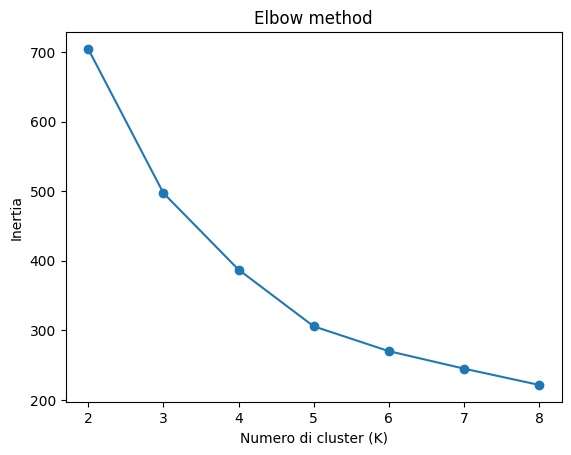

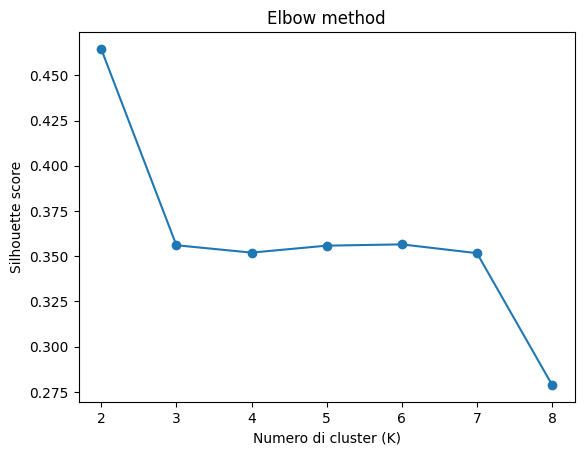

In [10]:
def plot_inertia(inertia_vec, k_range):
    plt.figure()
    plt.plot(k_range, inertia_vec, marker='o')
    plt.xlabel("Numero di cluster (K)")
    plt.ylabel("Inertia")
    plt.title("Elbow method")
    plt.show()

def plot_silhouette(silhouette_vec, k_range):
    plt.figure()
    plt.plot(k_range, silhouette_vec, marker='o')
    plt.xlabel("Numero di cluster (K)")
    plt.ylabel("Silhouette score")
    plt.title("Elbow method")
    plt.show()

plot_inertia(inertia, K_range)
plot_silhouette(sil_scores, K_range)


In [158]:
# Top cluster
k = 4
kmeans = KMeans(n_clusters=k, random_state=42, n_init=20)

df_clusters["cluster"] = kmeans.fit_predict(X_scaled)

In [159]:
centroids_scaled = kmeans.cluster_centers_
centroids = scaler.inverse_transform(centroids_scaled)

cluster_summary = (
    pd.DataFrame(centroids, columns=features)
    .assign(cluster=range(k))
)

cluster_summary

,mean_temp,std_temp,rain_total,days_rain,snow_total,days_snow,mean_daylight,mean_sunshine,cluster
0,21.712407,4.725469,16277.838889,2138.962963,29.883519,8.351852,43726.122392,37051.992572,0
1,6.393940,8.433678,21611.630769,3381.923077,4175.505385,1070.615385,44446.745923,25451.213740,1
2,24.588988,1.439451,57145.263492,6268.190476,32.451111,8.111111,43648.159301,35181.511200,2
3,10.937281,8.626440,20414.621212,2951.909091,1445.196667,358.393939,44044.739563,30405.560288,3


In [160]:
df_clusters['country'] = df_clusters['capital'].map(capital_to_country)
df_clusters.head(5)

,capital,mean_temp,std_temp,rain_total,days_rain,snow_total,days_snow,mean_daylight,mean_sunshine,cluster,country,pca1,pca2
0,Abuja,26.823444,2.200733,38576.9,4551,0.00,0,43653.205642,33435.919106,2,Nigeria,-1.353323,0.186800
1,Accra,26.848335,1.460698,20232.3,3841,0.00,0,43638.082460,36090.631905,0,Ghana,-1.455092,-0.616650
2,Addis Ababa,15.732666,1.372649,50712.2,4856,0.00,0,43653.205642,37502.042483,2,Ethiopia,-1.280265,0.348828
3,Algiers,18.433478,5.715757,18498.8,2412,15.82,6,43878.875057,36932.462103,0,Algeria,-0.063195,-1.246362
4,Alofi,25.278135,1.320144,54899.8,5162,0.00,0,43578.573185,35245.005225,2,Niue,-1.805503,0.616555


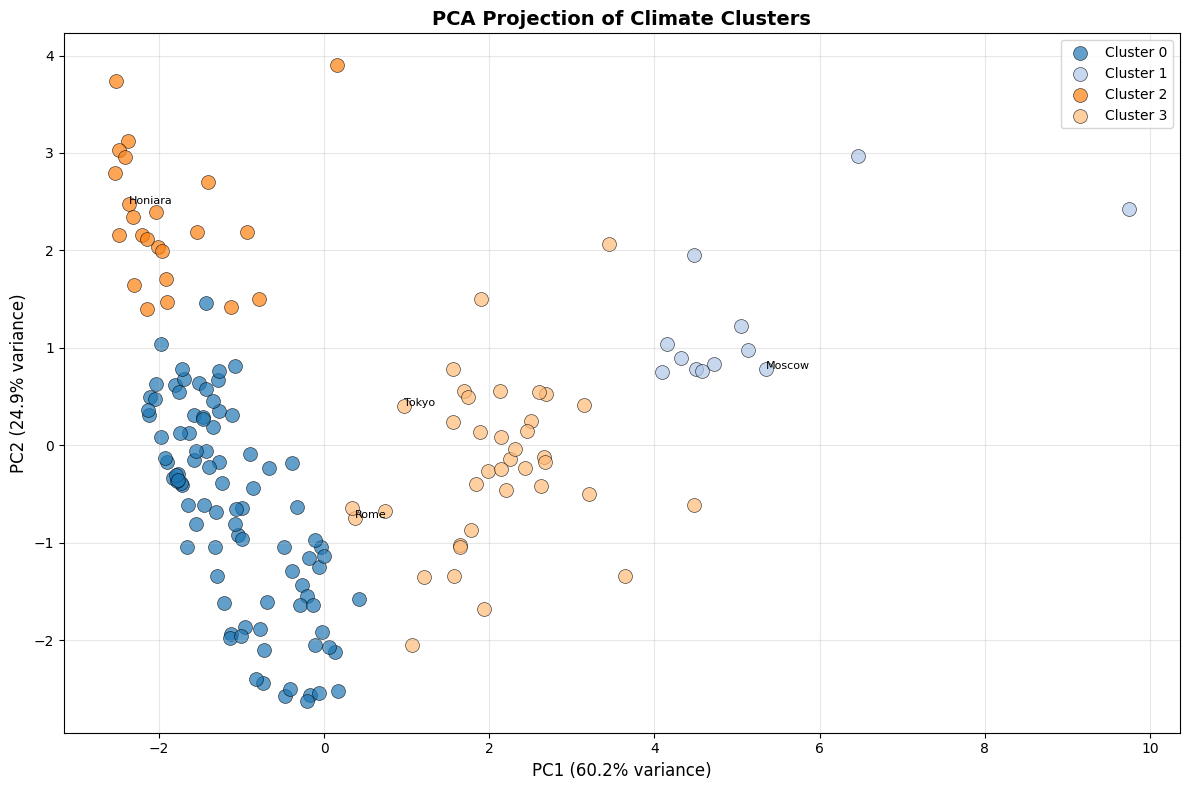

In [180]:
def plot_PCA(df_cluster_assignment, capitals = ['Rome', 'Honiara', 'Tokyo', 'Moscow']):
    # Plot PCA projection with cluster colors
    plt.figure(figsize=(12, 8))

    # Use tab10 colormap
    cmap = matplotlib.colormaps.get_cmap('tab20')
    colors = [cmap(i) for i in range(k)]

    # Plot each cluster
    for cluster_id in range(k):
        cluster_data = df_cluster_assignment[df_cluster_assignment['cluster'] == cluster_id]
        plt.scatter(
            cluster_data['pca1'], 
            cluster_data['pca2'],
            c=[colors[cluster_id]],
            label=f'Cluster {cluster_id}',
            alpha=0.7,
            s=100,
            edgecolors='black',
            linewidth=0.5
        )

    # Add labels for some capitals
    for capital in capitals:
        row = df_cluster_assignment[df_cluster_assignment["capital"] == capital]
        if not row.empty:
            plt.annotate(
                capital, 
                (row['pca1'].values[0], row['pca2'].values[0]),
                fontsize=8,
                alpha=1
            )

    plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)', fontsize=12)
    plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)', fontsize=12)
    plt.title('PCA Projection of Climate Clusters', fontsize=14, fontweight='bold')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_PCA(df_clusters)

In [11]:
import geopandas as gpd

def plot_world(df_cluster_assignment, method=""):
    # World map data
    world_url = "https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip"
    world = gpd.read_file(world_url)

    # Merge temperature change data
    world_clusters = world.merge(
        df_cluster_assignment,
        how="left",
        left_on="NAME",
        right_on="country"
    )

    fig, ax = plt.subplots(1, 1, figsize=(18, 9))

    world_clusters.plot(
        column="cluster",
        categorical=True,
        cmap="tab20",          # colori discreti
        linewidth=0.5,
        edgecolor="black",
        legend=True,
        ax=ax,
        missing_kwds={
            "color": "whitesmoke",
            "label": "No data"
        }
    )

    ax.set_title(
        f"Global Climate Clusters (based on {method})",
        fontsize=16
    )

    ax.axis("off")
    plt.show()

plot_world(df_clusters, "K-Means")

NameError: name 'df_clusters' is not defined

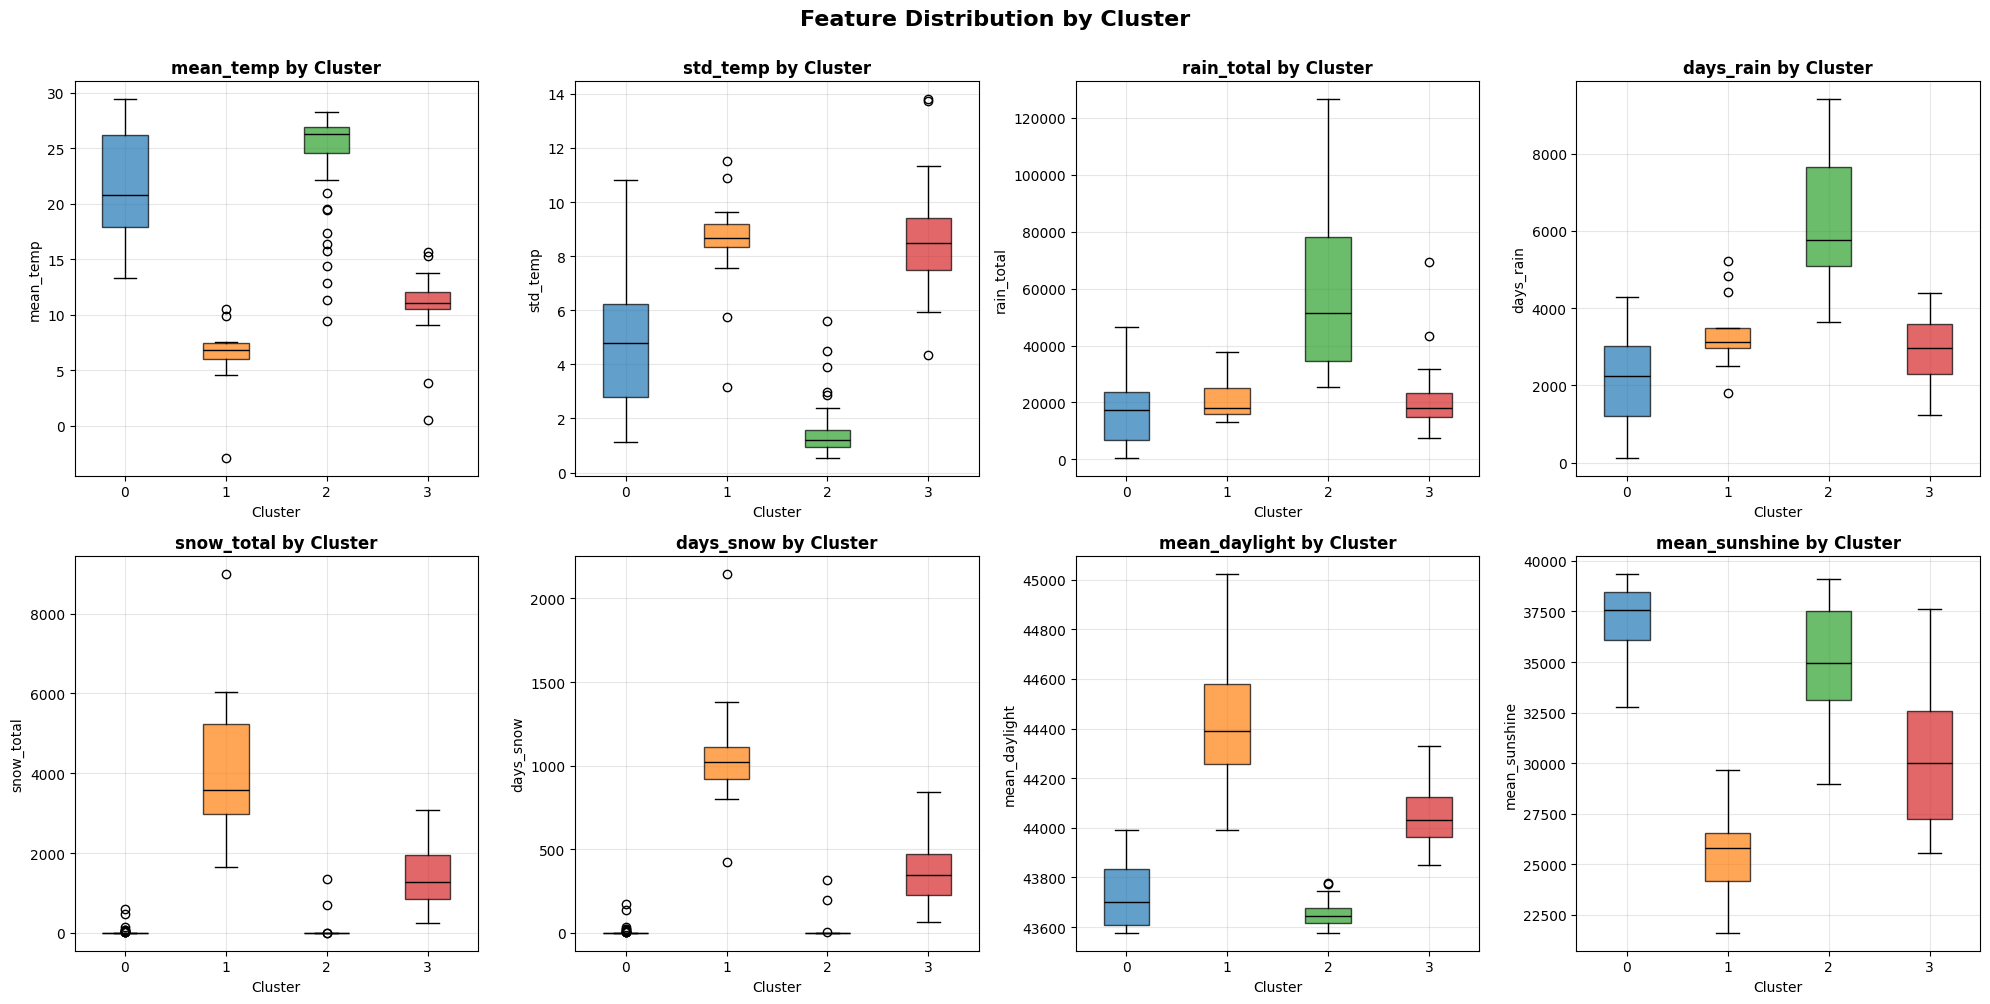

In [174]:
def plot_boxplots(df_cluster_assignment, n_clusters):
    fig, axes = plt.subplots(2, 4, figsize=(20, 10))
    axes = axes.flatten()

    # Use tab10 colormap (same as the map)
    cmap = matplotlib.colormaps.get_cmap('tab10')
    cluster_colors = {i: cmap(i) for i in range(n_clusters)}

    for i, feature in enumerate(features):
        ax = axes[i]
        
        # Create boxplot with colors
        box_data = [df_cluster_assignment[df_cluster_assignment['cluster'] == c][feature].values for c in range(n_clusters)]
        bp = ax.boxplot(box_data, tick_labels=range(n_clusters), patch_artist=True, 
                        medianprops={'color': 'black'}, boxprops={'alpha': 0.7, 'edgecolor': 'black'})
        
        # Apply colors to boxes
        for patch, cluster_id in zip(bp['boxes'], range(n_clusters)):
            patch.set_facecolor(cluster_colors[cluster_id])
        

        # Style the plot
        ax.set_title(f'{feature} by Cluster', fontsize=12, fontweight='bold')
        ax.set_xlabel('Cluster', fontsize=10)
        ax.set_ylabel(feature, fontsize=10)
        ax.grid(True, alpha=0.3)

    plt.suptitle('Feature Distribution by Cluster', fontsize=16, fontweight='bold', y=1.00)
    plt.tight_layout()
    plt.show()

plot_boxplots(df_clusters, k)

## DBSCAN

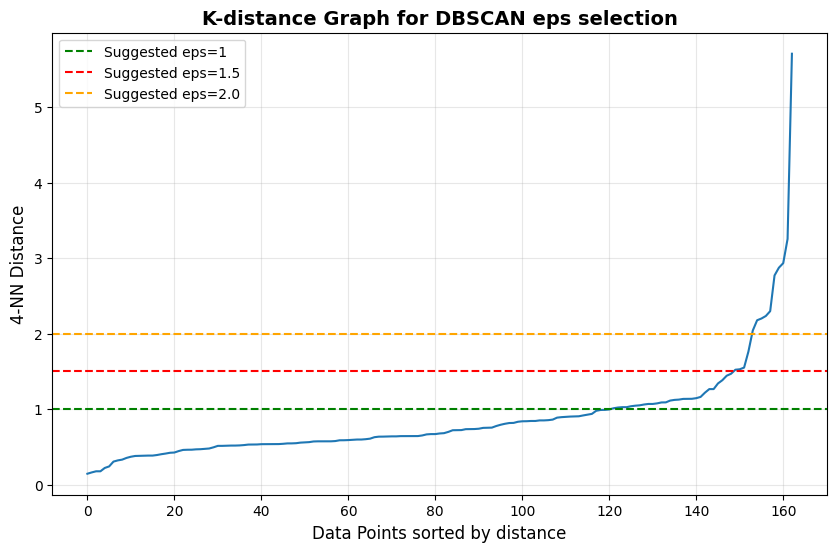

In [125]:
from sklearn.neighbors import NearestNeighbors

""" clustering = DBSCAN(eps=3, min_samples=2).fit(X_scaled)
df_clusters["cluster"] = clustering.labels_ """

# Calculate k-nearest neighbors distances
min_samples = 5
k_nn = min_samples - 1

neighbors = NearestNeighbors(n_neighbors=k_nn)
neighbors_fit = neighbors.fit(X_scaled)
distances, indices = neighbors_fit.kneighbors(X_scaled)

# Sort distances
distances = np.sort(distances[:, k-1], axis=0)

# Plot k-distance graph
plt.figure(figsize=(10, 6))
plt.plot(distances)
plt.xlabel('Data Points sorted by distance', fontsize=12)
plt.ylabel(f'{k_nn}-NN Distance', fontsize=12)
plt.title('K-distance Graph for DBSCAN eps selection', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.axhline(y=1, color='g', linestyle='--', label='Suggested eps=1')
plt.axhline(y=1.5, color='r', linestyle='--', label='Suggested eps=1.5')
plt.axhline(y=2.0, color='orange', linestyle='--', label='Suggested eps=2.0')
plt.legend()
plt.show()

#eps = 1.25

In [127]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score

# Test different eps and min_samples combinations
results = []

epss = [0.5, 1.0, 1.25, 1.5, 2.0, 2.5, 3.0]
min_samples_list = [3, 4, 5, 6]

for eps in epss:
    for min_samples in min_samples_list:
        dbscan = DBSCAN(eps=eps, min_samples=min_samples)
        labels = dbscan.fit_predict(X_scaled)
        
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = list(labels).count(-1)
        
        # Calculate silhouette only if we have valid clusters
        if n_clusters > 1 and n_noise < len(labels) - 1:
            sil_score = silhouette_score(X_scaled, labels)
        else:
            sil_score = -1
        
        results.append({
            'eps': eps,
            'min_samples': min_samples,
            'n_clusters': n_clusters,
            'n_noise': n_noise,
            'silhouette': sil_score
        })
# Show results
results_df = pd.DataFrame(results)
print(results_df.sort_values('silhouette', ascending=False).head(10))

     eps  min_samples  n_clusters  n_noise  silhouette
12  1.50            3           2        7    0.389113
8   1.25            3           2       15    0.336699
9   1.25            4           2       15    0.336699
10  1.25            5           2       16    0.330274
11  1.25            6           2       17    0.323234
6   1.00            5           2       31    0.296473
5   1.00            4           2       24    0.296246
7   1.00            6           2       35    0.275792
4   1.00            3           3       21    0.190307
3   0.50            6           2      144   -0.095656


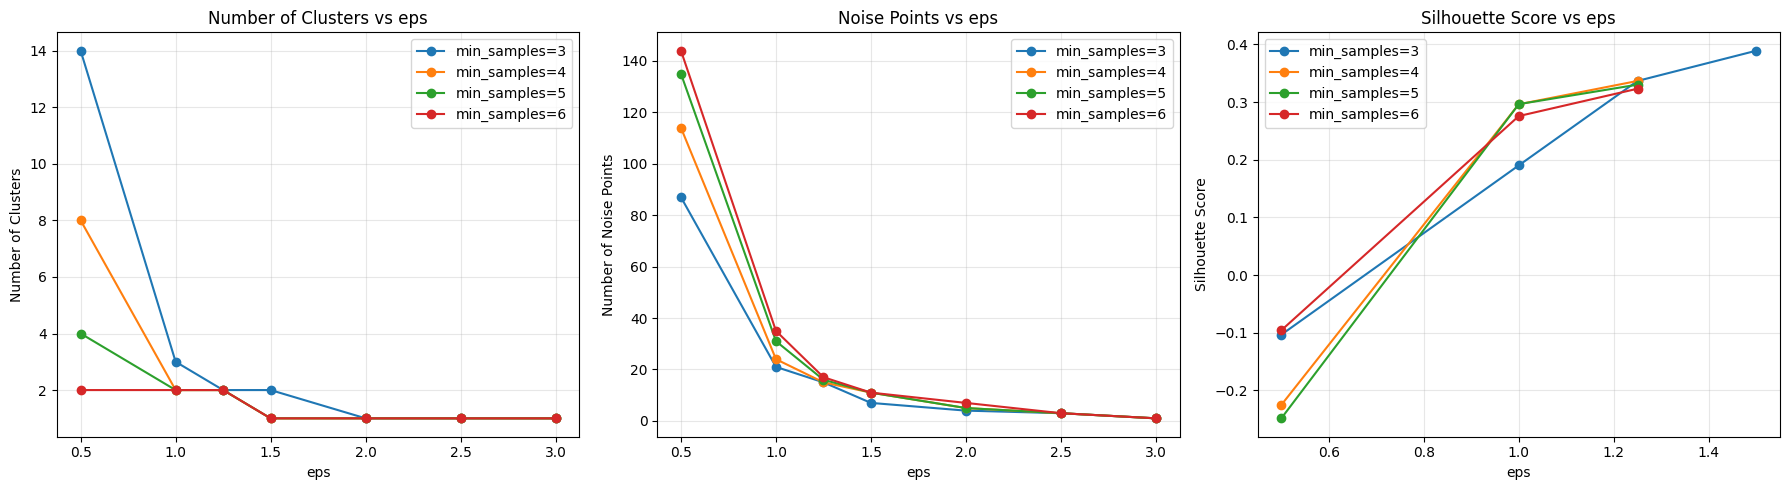

In [128]:
# Plot results
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Number of clusters
for min_s in min_samples_list:
    subset = results_df[results_df['min_samples'] == min_s]
    axes[0].plot(subset['eps'], subset['n_clusters'], marker='o', label=f'min_samples={min_s}')
axes[0].set_xlabel('eps')
axes[0].set_ylabel('Number of Clusters')
axes[0].set_title('Number of Clusters vs eps')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Noise points
for min_s in min_samples_list:
    subset = results_df[results_df['min_samples'] == min_s]
    axes[1].plot(subset['eps'], subset['n_noise'], marker='o', label=f'min_samples={min_s}')
axes[1].set_xlabel('eps')
axes[1].set_ylabel('Number of Noise Points')
axes[1].set_title('Noise Points vs eps')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Plot 3: Silhouette score
for min_s in min_samples_list:
    subset = results_df[results_df['min_samples'] == min_s]
    valid = subset[subset['silhouette'] > -1]
    axes[2].plot(valid['eps'], valid['silhouette'], marker='o', label=f'min_samples={min_s}')
axes[2].set_xlabel('eps')
axes[2].set_ylabel('Silhouette Score')
axes[2].set_title('Silhouette Score vs eps')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Number of clusters: 10
Number of noise points: 72

Cluster distribution:
cluster
-1    72
 0     5
 1    11
 2    35
 3     8
 4    11
 5     3
 6     6
 7     4
 8     4
 9     4
Name: count, dtype: int64


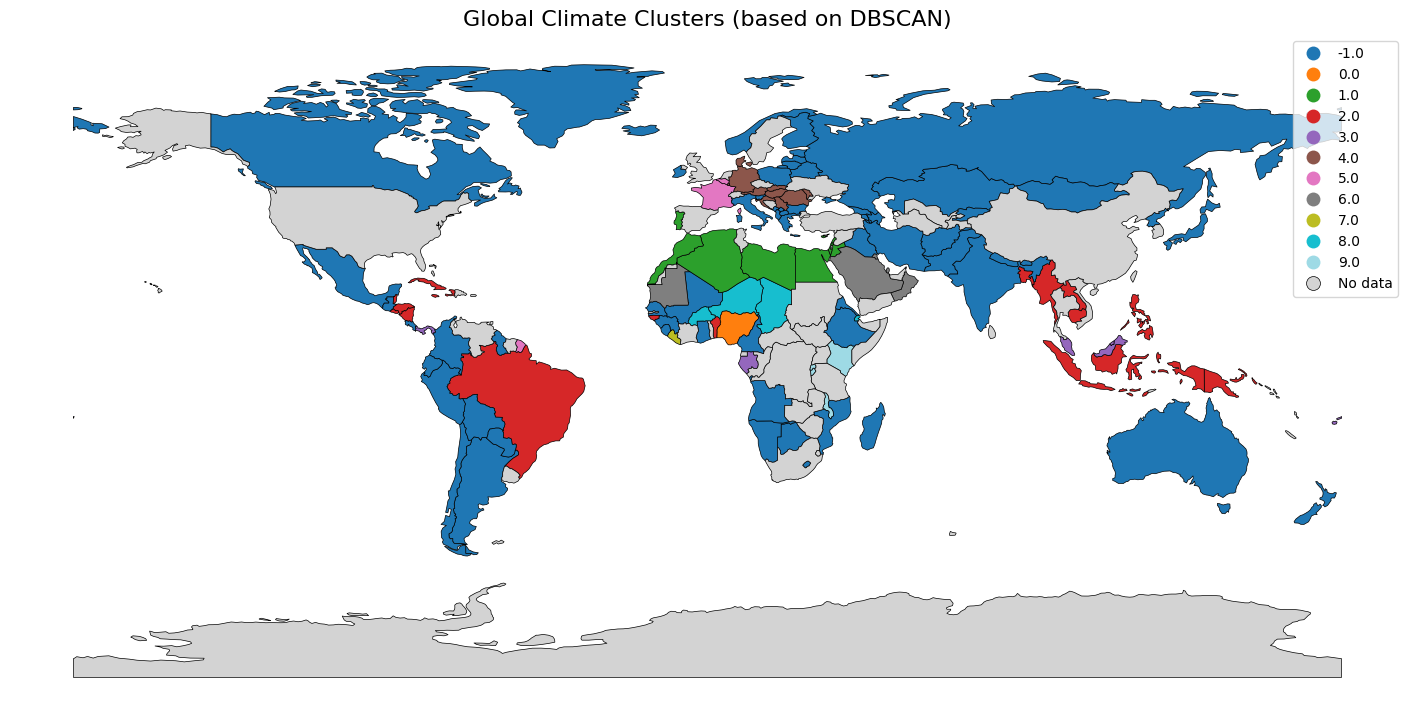

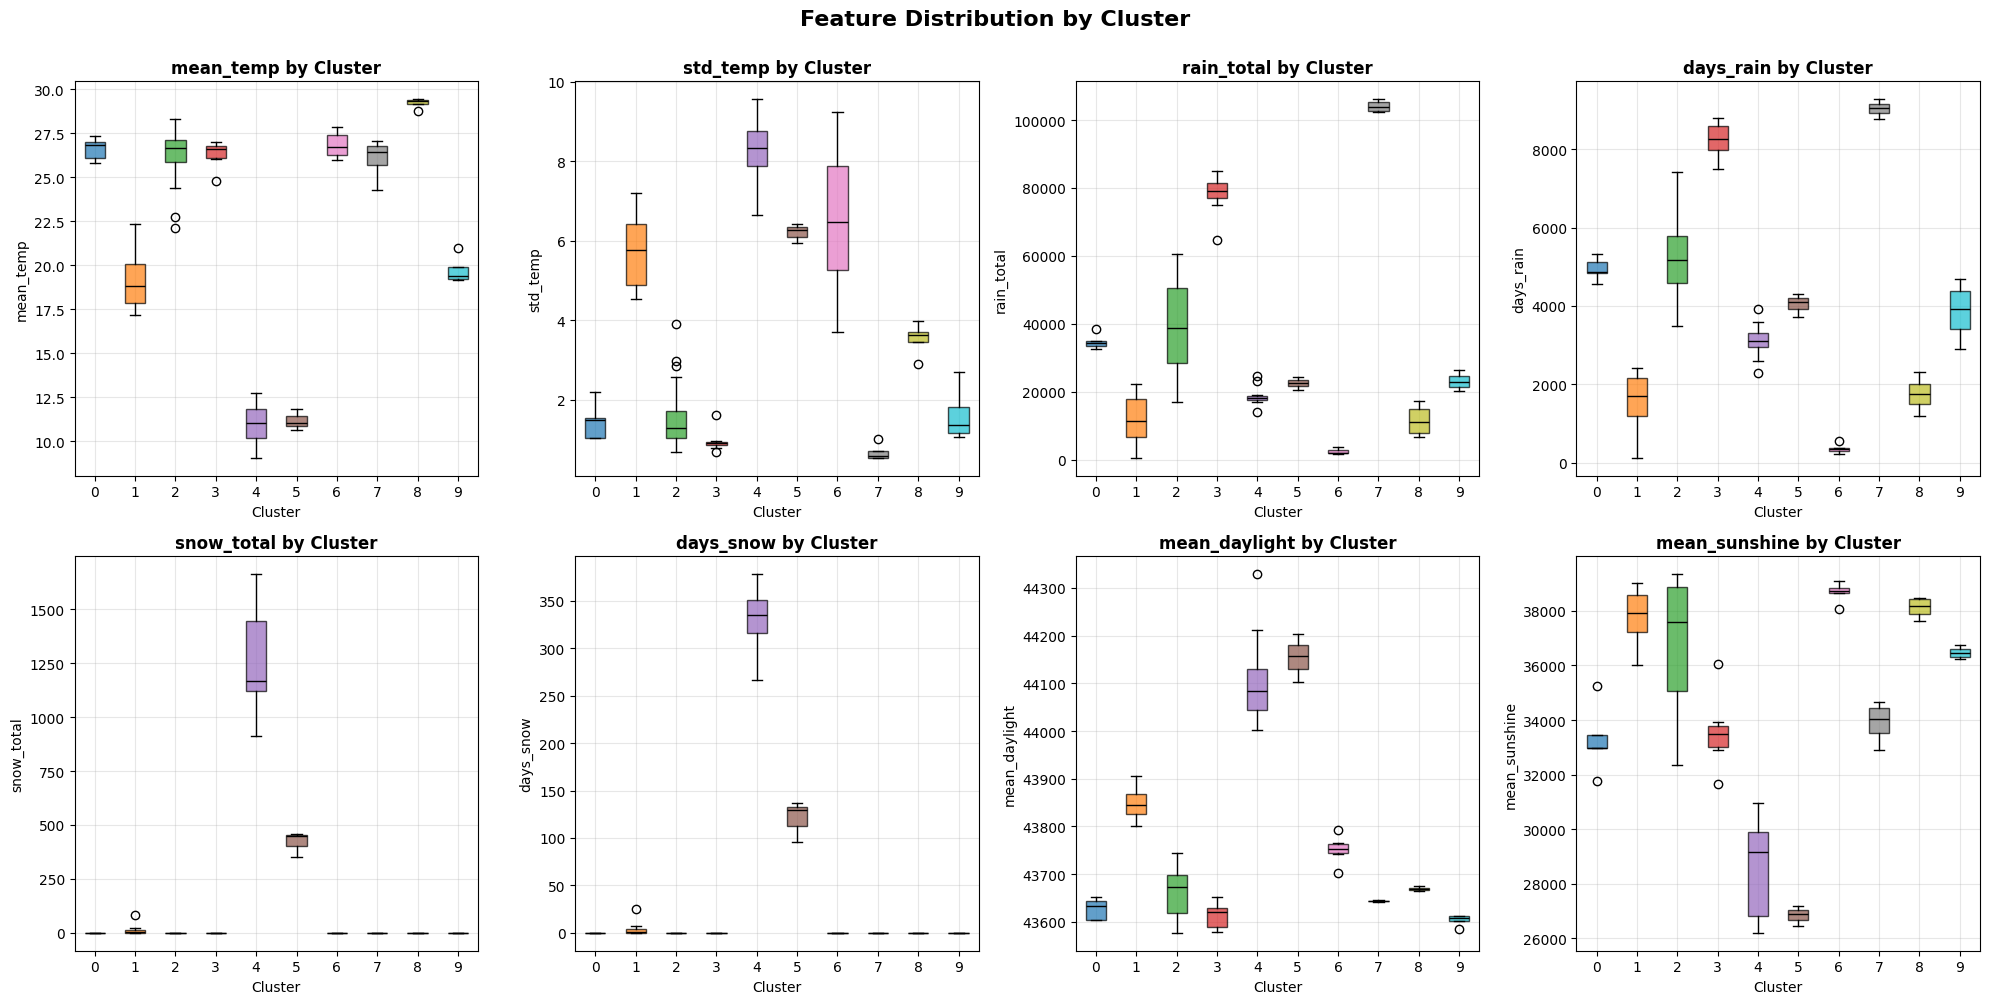

In [154]:
# Choose best parameters (example)
best_eps = 0.6
best_min_samples = 4

dbscan = DBSCAN(eps=best_eps, min_samples=best_min_samples)
df_clusters['cluster'] = dbscan.fit_predict(X_scaled)

num_clusters = len(set(df_clusters['cluster'])) - (1 if -1 in df_clusters['cluster'].values else 0)

print(f"Number of clusters: {num_clusters}")
print(f"Number of noise points: {list(df_clusters['cluster']).count(-1)}")
print(f"\nCluster distribution:\n{df_clusters['cluster'].value_counts().sort_index()}")

plot_world(df_clusters, method="DBSCAN")

plot_boxplots(df_clusters, num_clusters)

## Cure clustering

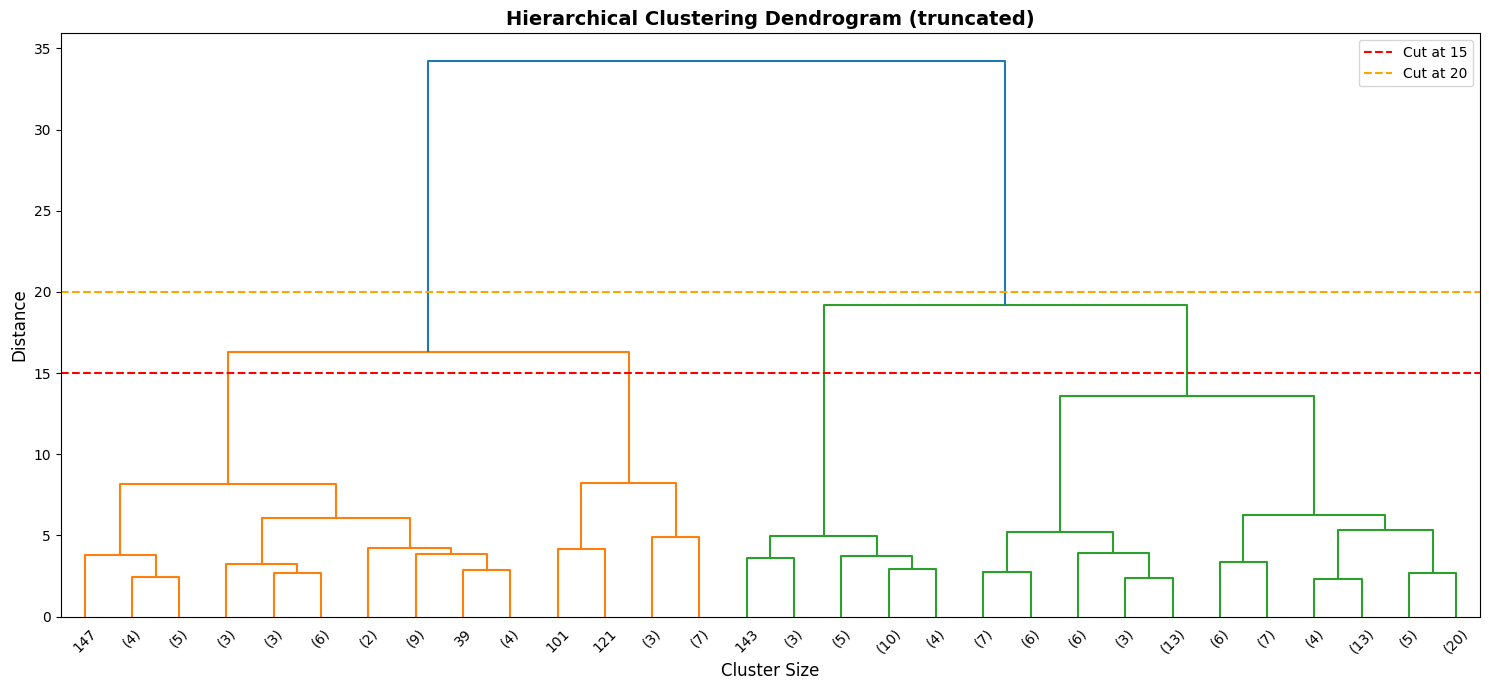

In [175]:
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering

# Create linkage matrix for dendrogram
linkage_matrix = linkage(X_scaled, method='ward')

# Plot dendrogram
plt.figure(figsize=(15, 7))
dendrogram(linkage_matrix, truncate_mode='lastp', p=30)
plt.title('Hierarchical Clustering Dendrogram (truncated)', fontsize=14, fontweight='bold')
plt.xlabel('Cluster Size', fontsize=12)
plt.ylabel('Distance', fontsize=12)
plt.axhline(y=15, color='r', linestyle='--', label='Cut at 15')
plt.axhline(y=20, color='orange', linestyle='--', label='Cut at 20')
plt.legend()
plt.tight_layout()
plt.show()

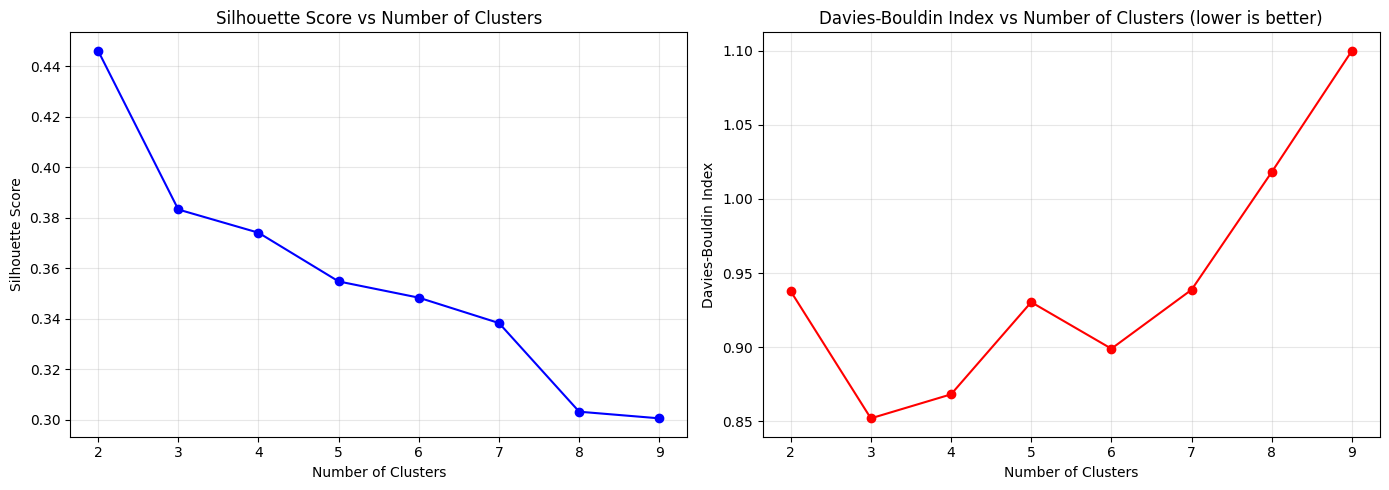

In [177]:
from sklearn.metrics import silhouette_score, davies_bouldin_score

# Test different number of clusters
sil_scores_agg = []
db_scores = []
k_range = range(2, 10)

for n_clusters in k_range:
    agg = AgglomerativeClustering(n_clusters=n_clusters, linkage='ward')
    labels = agg.fit_predict(X_scaled)
    
    sil_scores_agg.append(silhouette_score(X_scaled, labels))
    db_scores.append(davies_bouldin_score(X_scaled, labels))

# Plot metrics
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(k_range, sil_scores_agg, marker='o', color='blue')
axes[0].set_xlabel('Number of Clusters')
axes[0].set_ylabel('Silhouette Score')
axes[0].set_title('Silhouette Score vs Number of Clusters')
axes[0].grid(True, alpha=0.3)

axes[1].plot(k_range, db_scores, marker='o', color='red')
axes[1].set_xlabel('Number of Clusters')
axes[1].set_ylabel('Davies-Bouldin Index')
axes[1].set_title('Davies-Bouldin Index vs Number of Clusters (lower is better)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [182]:
# Choose best number of clusters
n_clusters_agg = 5

# Apply Agglomerative Clustering
agg_clustering = AgglomerativeClustering(n_clusters=n_clusters_agg, linkage='ward')
df_clusters['cluster'] = agg_clustering.fit_predict(X_scaled)

print(f"Number of clusters: {n_clusters_agg}")
print(f"\nCluster distribution:\n{df_clusters['cluster'].value_counts().sort_index()}")

# Compute centroids (manually, since AgglomerativeClustering doesn't provide them)
centroids = df_clusters.groupby('cluster')[features].mean()
print(f"\nCluster centroids:\n{centroids}")

Number of clusters: 5

Cluster distribution:
cluster
0    12
1    38
2    23
3    55
4    35
Name: count, dtype: int64

Cluster centroids:
         mean_temp  std_temp    rain_total    days_rain   snow_total  \
cluster                                                                
0         6.327116  8.871857  21181.441667  3229.833333  4386.684167   
1        11.346568  8.378749  20711.610526  2971.131579  1329.950263   
2        23.210594  1.335662  85668.956522  8008.565217    88.881739   
3        24.069795  1.887408  36769.518182  4787.527273     1.484000   
4        22.881438  5.165392  11424.588571  1503.028571     9.342000   

           days_snow  mean_daylight  mean_sunshine  
cluster                                             
0        1124.500000   44422.116436   25771.537903  
1         331.526316   44051.976135   30731.962231  
2          22.217391   43639.579866   33407.892426  
3           0.327273   43646.878386   36157.950798  
4           2.457143   43742.845976   

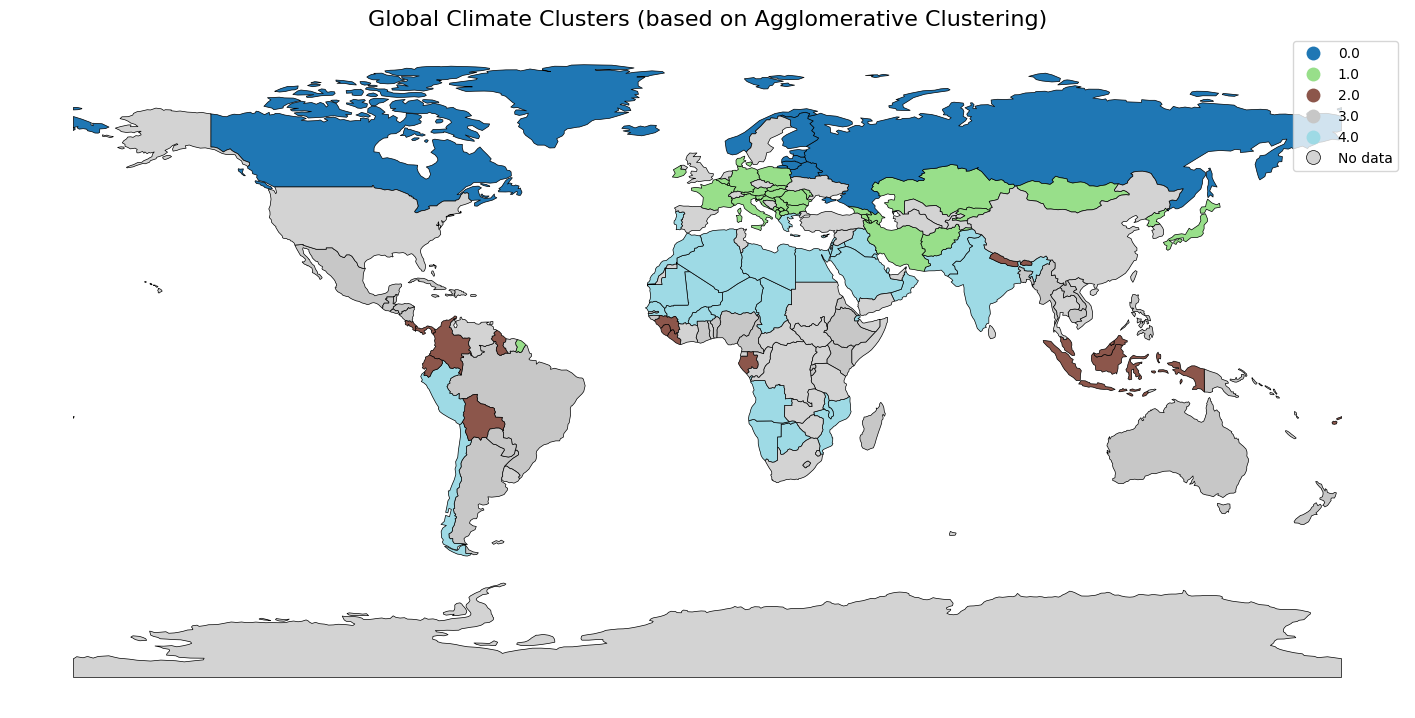

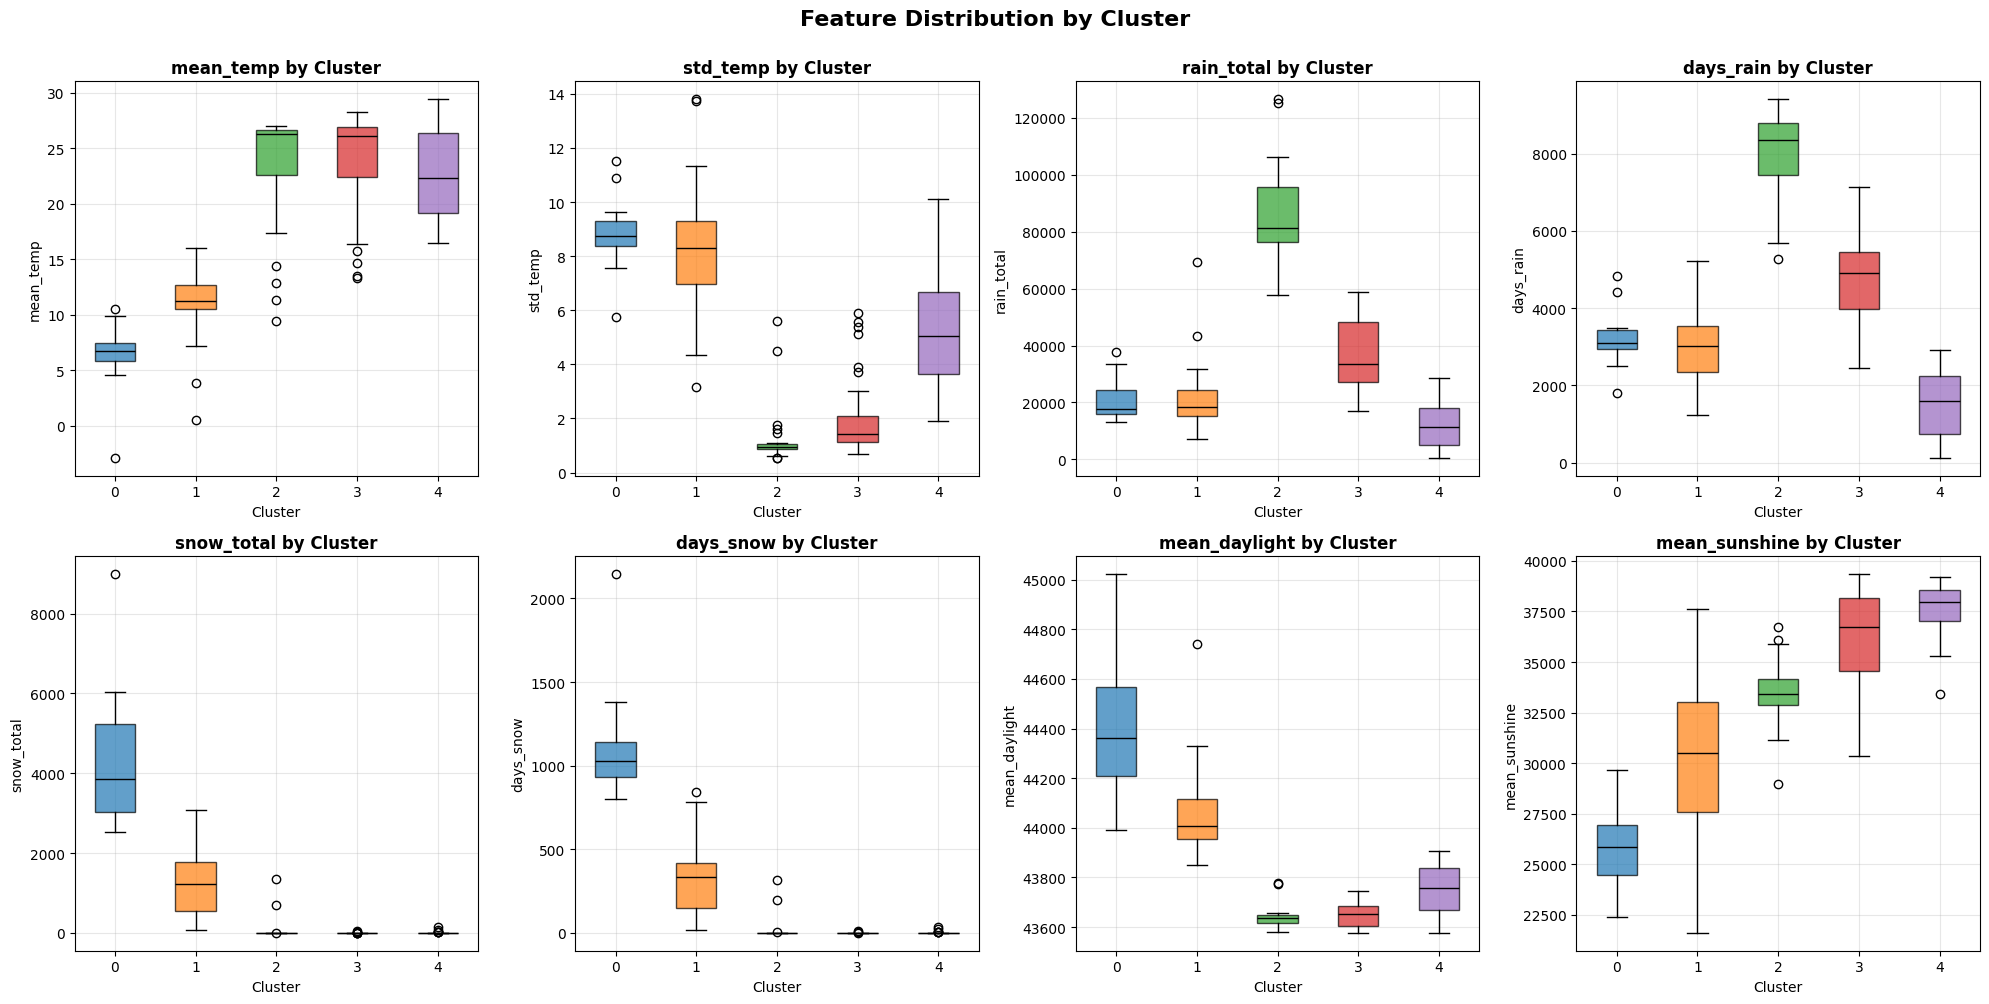

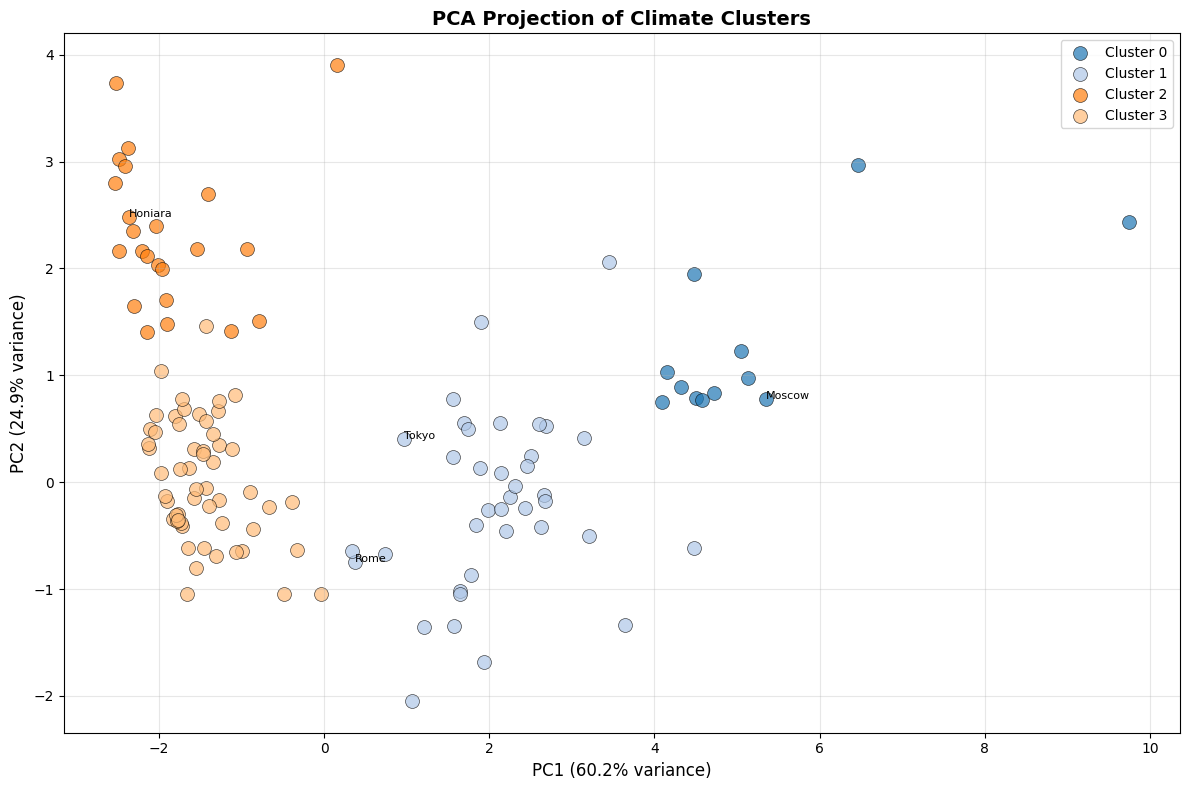

In [184]:
# Plot world map
plot_world(df_clusters, method="Agglomerative Clustering")

# Plot boxplots
plot_boxplots(df_clusters, n_clusters_agg)

plot_PCA(df_clusters)

# Clustering per capitale per decennio

In [8]:
df_clusters_first = aggregation_per_capital_decade[aggregation_per_capital_decade["decade"] == "1995-2004"]
print(df_clusters_first.head(5))

df_clusters_second = aggregation_per_capital_decade[aggregation_per_capital_decade["decade"] == "2005-2014"]
print(df_clusters_second.head(5))

df_clusters_third = aggregation_per_capital_decade[aggregation_per_capital_decade["decade"] == "2015-2024"]
print(df_clusters_third.head(5))

        capital     decade  mean_temp  std_temp  rain_total  days_rain  \
0         Abuja  1995-2004  26.734068  2.181188     14457.2       1628   
3         Accra  1995-2004  26.750808  1.484128      5573.5       1109   
6   Addis Ababa  1995-2004  15.726512  1.351592     18248.9       1625   
9       Algiers  1995-2004  18.275404  5.749907      5509.4        757   
12        Alofi  1995-2004  25.143759  1.361741     16639.4       1673   

    snow_total  days_snow  mean_daylight  mean_sunshine  
0          0.0          0   43653.066091   33536.826351  
3          0.0          0   43637.997613   36487.693474  
6          0.0          0   43653.066091   37895.470274  
9          0.0          0   43878.199258   37499.837753  
12         0.0          0   43578.886734   35927.494681  
        capital     decade  mean_temp  std_temp  rain_total  days_rain  \
1         Abuja  2005-2014  26.907694  2.274049     13825.6       1579   
4         Accra  2005-2014  26.841073  1.497571      6189.2

## 1995-2004

Silhouette scores: [np.float64(0.4646026084236927), np.float64(0.3560750131113529), np.float64(0.3520002545500563), np.float64(0.35584619191142947), np.float64(0.3565566874434026), np.float64(0.3517068125556025), np.float64(0.27886136665008016)]
Inertia scores: [704.5133238927102, 497.38691937637026, 387.2767789072108, 305.7747106344214, 270.0548191009326, 244.93664488127402, 221.4986173564403]


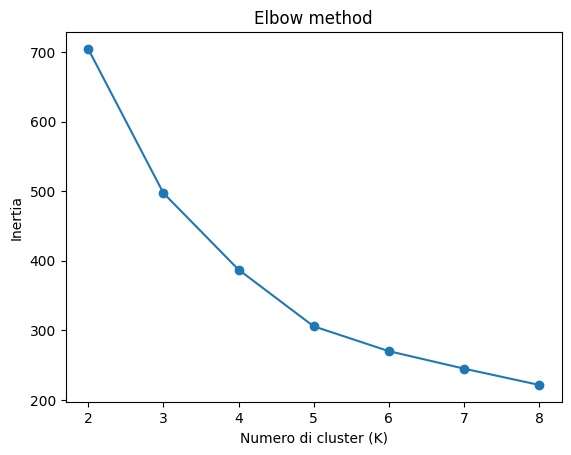

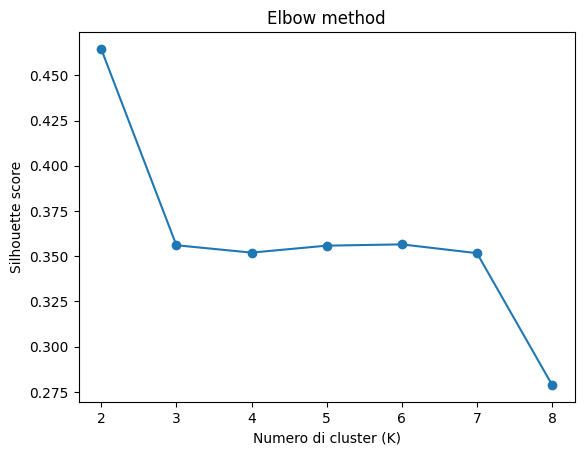

In [18]:
# Scaling
features = ['mean_temp', 'std_temp', 'rain_total', 'days_rain', 'snow_total', 'days_snow', 'mean_daylight', 'mean_sunshine']
X = df_clusters_first[features].copy()

#Log transform per asimmetria - consigliato ma da capire
#X["rain_total"] = np.log1p(X["rain_total"])
#X["snow_total"] = np.log1p(X["snow_total"])

#X.head(5)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

sil_scores = []
inertia = []

K_range = range(2, 9)

for k in range(2, 9):
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = km.fit_predict(X_scaled)
    sil_scores.append(silhouette_score(X_scaled, labels))
    inertia.append(km.inertia_)

print(f"Silhouette scores: {sil_scores}")
print(f"Inertia scores: {inertia}")


plot_inertia(inertia, K_range)
plot_silhouette(sil_scores, K_range)

In [ ]:
# Top cluster
k = 5
kmeans = KMeans(n_clusters=k, random_state=42, n_init=20)

df_clusters_first["cluster"] = kmeans.fit_predict(X_scaled)

C:\Users\gabri\AppData\Local\Temp\ipykernel_4608\858349062.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clusters_first["cluster"] = kmeans.fit_predict(X_scaled)


In [ ]:
centroids_scaled = kmeans.cluster_centers_
centroids = scaler.inverse_transform(centroids_scaled)

cluster_summary = (
    pd.DataFrame(centroids, columns=features)
    .assign(cluster=range(k))
)

cluster_summary

,mean_temp,std_temp,rain_total,days_rain,snow_total,days_snow,mean_daylight,mean_sunshine,cluster
0,10.067753,8.392364,6947.684375,1034.531250,501.162813,1.271562e+02,44075.157631,29712.979112,0
1,20.472159,5.898985,4032.815385,521.307692,29.179231,7.615385e+00,43773.915127,37612.371582,1
2,23.325218,1.385571,27112.838462,2645.807692,27.930000,6.538462e+00,43641.368859,33746.283675,2
3,24.445466,1.705119,11050.053704,1509.481481,0.014259,4.973799e-14,43647.216601,36688.174750,3
4,5.784475,9.028588,6639.041667,1041.416667,1446.561667,3.795833e+02,44420.637451,25802.635268,4


In [ ]:
df_clusters_first['country'] = df_clusters_first['capital'].map(capital_to_country)
df_clusters_first.head(5)

C:\Users\gabri\AppData\Local\Temp\ipykernel_4608\2134424133.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clusters_first['country'] = df_clusters_first['capital'].map(capital_to_country)


,capital,decade,mean_temp,std_temp,rain_total,days_rain,snow_total,days_snow,mean_daylight,mean_sunshine,cluster,country
0,Abuja,1995-2004,26.734068,2.181188,14457.2,1628,0.0,0,43653.066091,33536.826351,3,Nigeria
3,Accra,1995-2004,26.750808,1.484128,5573.5,1109,0.0,0,43637.997613,36487.693474,3,Ghana
6,Addis Ababa,1995-2004,15.726512,1.351592,18248.9,1625,0.0,0,43653.066091,37895.470274,3,Ethiopia
9,Algiers,1995-2004,18.275404,5.749907,5509.4,757,0.0,0,43878.199258,37499.837753,1,Algeria
12,Alofi,1995-2004,25.143759,1.361741,16639.4,1673,0.0,0,43578.886734,35927.494681,3,Niue


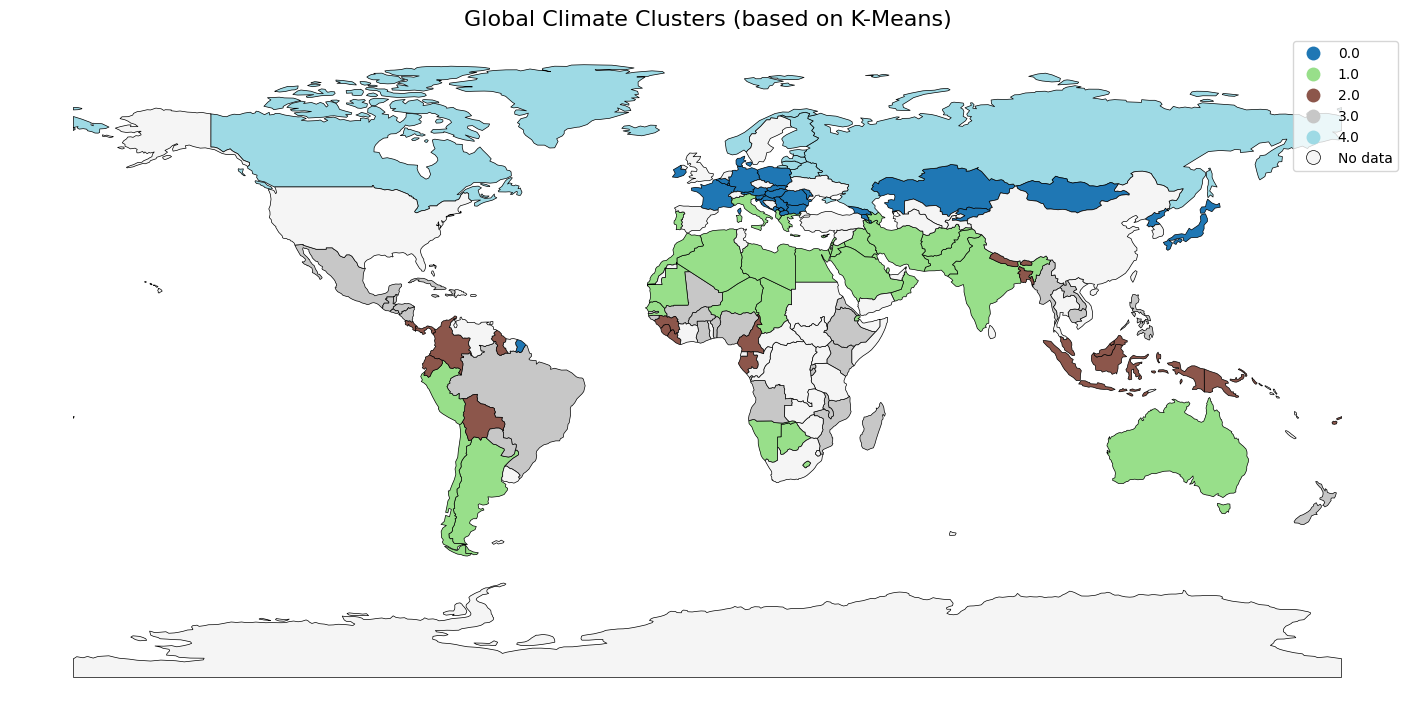

In [ ]:
plot_world(df_clusters_first, "K-Means")

Silhouette scores: [np.float64(0.4646026084236927), np.float64(0.3560750131113529), np.float64(0.3520002545500563), np.float64(0.35584619191142947), np.float64(0.3565566874434026), np.float64(0.3517068125556025), np.float64(0.27886136665008016)]
Inertia scores: [704.5133238927102, 497.38691937637026, 387.2767789072108, 305.7747106344214, 270.0548191009326, 244.93664488127402, 221.4986173564403]


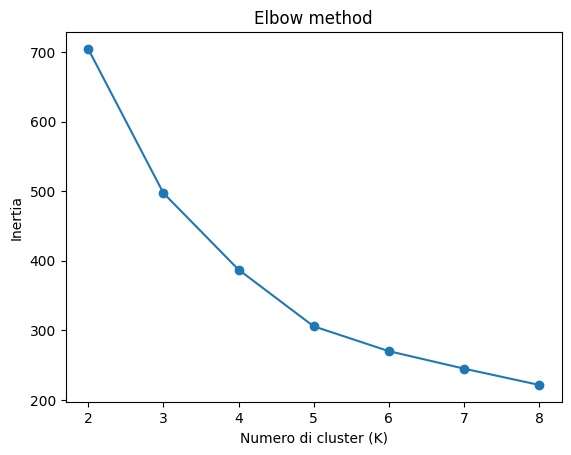

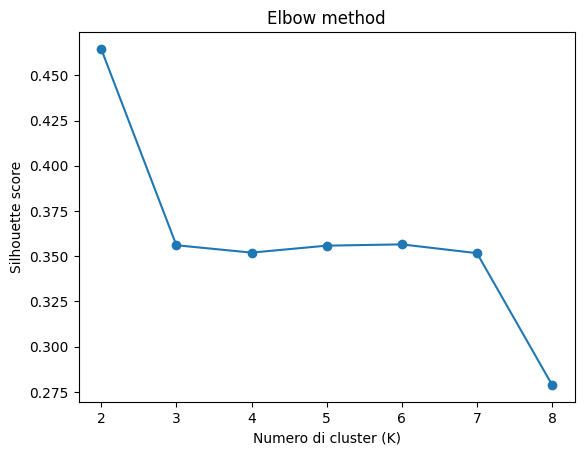

In [12]:
# Scaling
features = ['mean_temp', 'std_temp', 'rain_total', 'days_rain', 'snow_total', 'days_snow', 'mean_daylight', 'mean_sunshine']
X = df_clusters_first[features].copy()

#Log transform per asimmetria - consigliato ma da capire
#X["rain_total"] = np.log1p(X["rain_total"])
#X["snow_total"] = np.log1p(X["snow_total"])

#X.head(5)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

sil_scores = []
inertia = []

K_range = range(2, 9)

for k in range(2, 9):
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = km.fit_predict(X_scaled)
    sil_scores.append(silhouette_score(X_scaled, labels))
    inertia.append(km.inertia_)

print(f"Silhouette scores: {sil_scores}")
print(f"Inertia scores: {inertia}")


plot_inertia(inertia, K_range)
plot_silhouette(sil_scores, K_range)

In [13]:
# Top cluster
k = 5
kmeans = KMeans(n_clusters=k, random_state=42, n_init=20)

df_clusters_first["cluster"] = kmeans.fit_predict(X_scaled)

C:\Users\gabri\AppData\Local\Temp\ipykernel_4608\858349062.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clusters_first["cluster"] = kmeans.fit_predict(X_scaled)


In [14]:
centroids_scaled = kmeans.cluster_centers_
centroids = scaler.inverse_transform(centroids_scaled)

cluster_summary = (
    pd.DataFrame(centroids, columns=features)
    .assign(cluster=range(k))
)

cluster_summary

,mean_temp,std_temp,rain_total,days_rain,snow_total,days_snow,mean_daylight,mean_sunshine,cluster
0,10.067753,8.392364,6947.684375,1034.531250,501.162813,1.271562e+02,44075.157631,29712.979112,0
1,20.472159,5.898985,4032.815385,521.307692,29.179231,7.615385e+00,43773.915127,37612.371582,1
2,23.325218,1.385571,27112.838462,2645.807692,27.930000,6.538462e+00,43641.368859,33746.283675,2
3,24.445466,1.705119,11050.053704,1509.481481,0.014259,4.973799e-14,43647.216601,36688.174750,3
4,5.784475,9.028588,6639.041667,1041.416667,1446.561667,3.795833e+02,44420.637451,25802.635268,4


In [15]:
df_clusters_first['country'] = df_clusters_first['capital'].map(capital_to_country)
df_clusters_first.head(5)

C:\Users\gabri\AppData\Local\Temp\ipykernel_4608\2134424133.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clusters_first['country'] = df_clusters_first['capital'].map(capital_to_country)


,capital,decade,mean_temp,std_temp,rain_total,days_rain,snow_total,days_snow,mean_daylight,mean_sunshine,cluster,country
0,Abuja,1995-2004,26.734068,2.181188,14457.2,1628,0.0,0,43653.066091,33536.826351,3,Nigeria
3,Accra,1995-2004,26.750808,1.484128,5573.5,1109,0.0,0,43637.997613,36487.693474,3,Ghana
6,Addis Ababa,1995-2004,15.726512,1.351592,18248.9,1625,0.0,0,43653.066091,37895.470274,3,Ethiopia
9,Algiers,1995-2004,18.275404,5.749907,5509.4,757,0.0,0,43878.199258,37499.837753,1,Algeria
12,Alofi,1995-2004,25.143759,1.361741,16639.4,1673,0.0,0,43578.886734,35927.494681,3,Niue


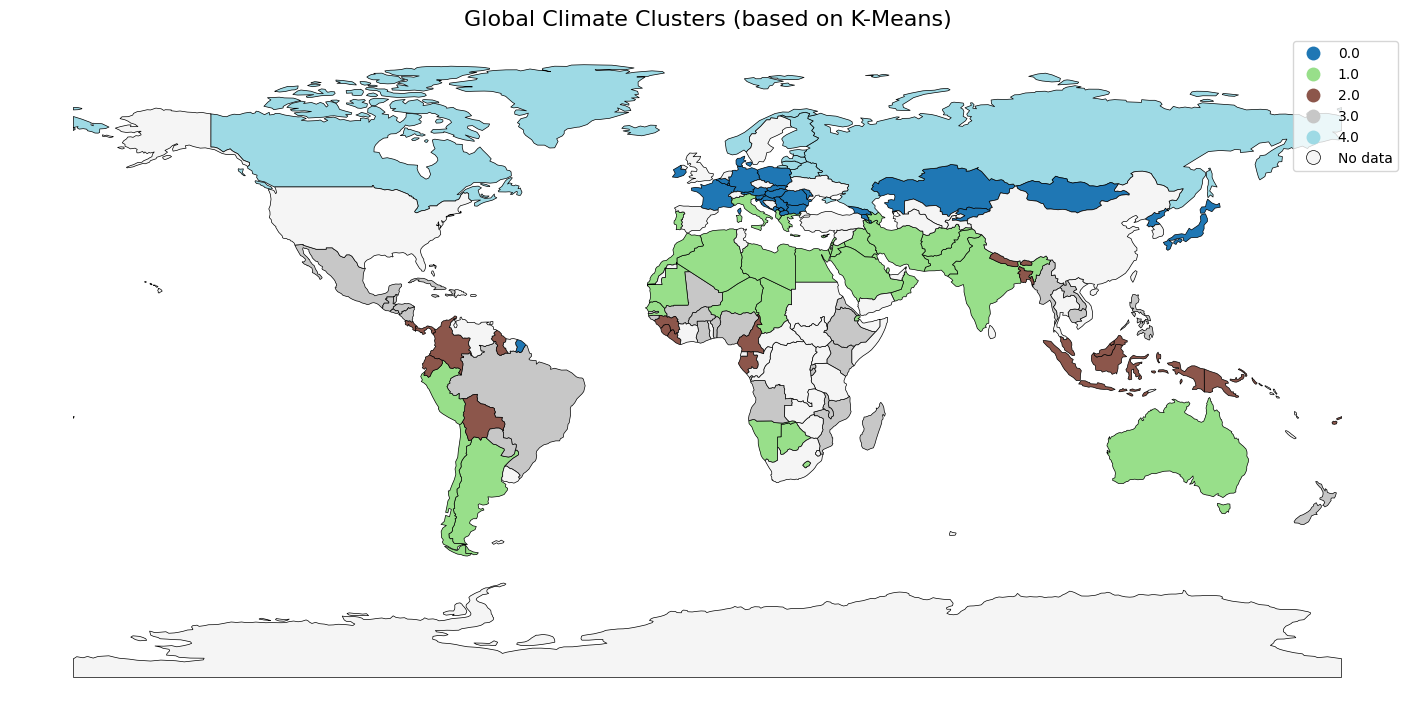

In [16]:
plot_world(df_clusters_first, "K-Means")

## 2005-2014

Silhouette scores: [np.float64(0.46851334443046283), np.float64(0.3652867129975443), np.float64(0.34773326723819753), np.float64(0.36747532579911396), np.float64(0.36619185051399966), np.float64(0.35423777551537544), np.float64(0.2833635551417875)]
Inertia scores: [694.1112511453208, 485.69953872597654, 388.87261168240644, 300.08531961735343, 267.1923170040589, 238.95884417144273, 221.69913954210688]


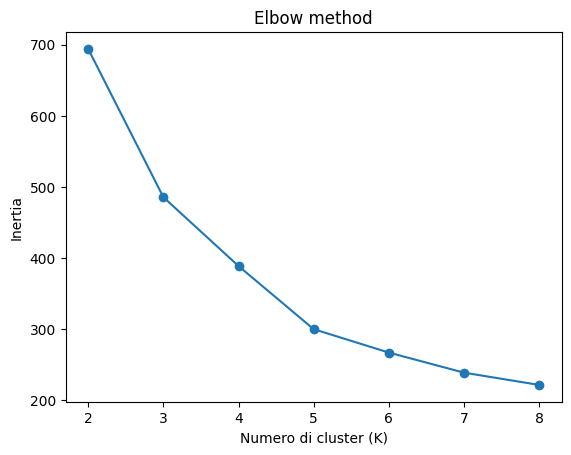

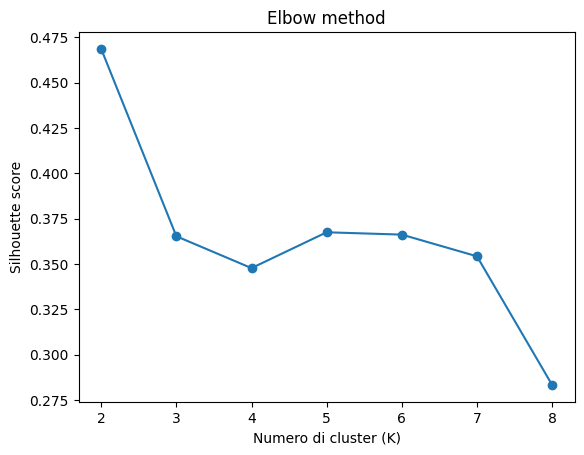

In [19]:
# Scaling
features = ['mean_temp', 'std_temp', 'rain_total', 'days_rain', 'snow_total', 'days_snow', 'mean_daylight', 'mean_sunshine']
X = df_clusters_second[features].copy()

#Log transform per asimmetria - consigliato ma da capire
#X["rain_total"] = np.log1p(X["rain_total"])
#X["snow_total"] = np.log1p(X["snow_total"])

#X.head(5)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

sil_scores = []
inertia = []

K_range = range(2, 9)

for k in range(2, 9):
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = km.fit_predict(X_scaled)
    sil_scores.append(silhouette_score(X_scaled, labels))
    inertia.append(km.inertia_)

print(f"Silhouette scores: {sil_scores}")
print(f"Inertia scores: {inertia}")


plot_inertia(inertia, K_range)
plot_silhouette(sil_scores, K_range)

In [20]:
# Top cluster
k = 5
kmeans = KMeans(n_clusters=k, random_state=42, n_init=20)

df_clusters_second["cluster"] = kmeans.fit_predict(X_scaled)

C:\Users\gabri\AppData\Local\Temp\ipykernel_4608\3055452850.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clusters_second["cluster"] = kmeans.fit_predict(X_scaled)


In [21]:
centroids_scaled = kmeans.cluster_centers_
centroids = scaler.inverse_transform(centroids_scaled)

cluster_summary = (
    pd.DataFrame(centroids, columns=features)
    .assign(cluster=range(k))
)

cluster_summary

,mean_temp,std_temp,rain_total,days_rain,snow_total,days_snow,mean_daylight,mean_sunshine,cluster
0,24.495651,1.726990,11695.150000,1522.259259,0.068704,0.018519,43648.772606,36370.361725,0
1,6.223751,9.136898,6865.191667,1065.750000,1313.182500,346.000000,44425.709260,26040.406033,1
2,21.233083,5.780135,3913.392105,503.657895,14.316842,4.131579,43764.633120,37781.431964,2
3,10.641881,8.477922,6896.123529,1005.911765,516.746176,129.264706,44069.364399,30400.207242,3
4,23.326190,1.242077,28084.196000,2695.920000,19.754000,4.480000,43637.460279,33254.797766,4


C:\Users\gabri\AppData\Local\Temp\ipykernel_4608\2007589274.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clusters_second['country'] = df_clusters_second['capital'].map(capital_to_country)


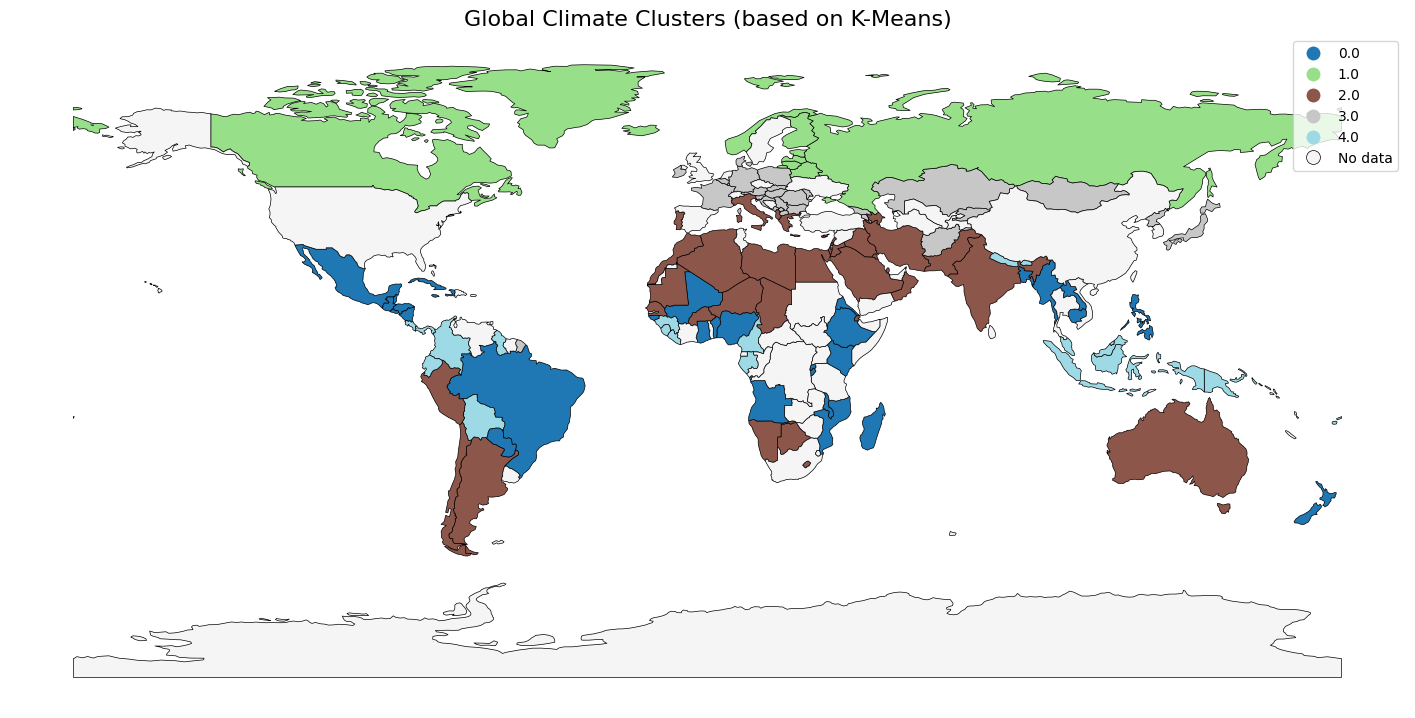

In [22]:
df_clusters_second['country'] = df_clusters_second['capital'].map(capital_to_country)
df_clusters_second.head(5)
plot_world(df_clusters_second, "K-Means")

In [25]:
# Analisi della stabilità dei cluster tra i due decenni

# Per ogni capitale, trova le altre capitali che erano nel suo stesso cluster in entrambi i periodi
def calculate_cluster_stability(df1, df2, period1='1995-2004', period2='2005-2014'):
    """
    Calcola la stabilità dei cluster confrontando la composizione dei gruppi
    """
    # Merge dei due dataframe
    merged = df1[['capital', 'cluster']].merge(
        df2[['capital', 'cluster']], 
        on='capital', 
        suffixes=(f'_{period1}', f'_{period2}')
    )
    
    stability_scores = []
    
    # Per ogni capitale
    for idx, row in merged.iterrows():
        capital = row['capital']
        cluster_old = row[f'cluster_{period1}']
        cluster_new = row[f'cluster_{period2}']
        
        # Trova le capitali che erano nel suo stesso cluster nel primo periodo
        same_cluster_old = set(merged[merged[f'cluster_{period1}'] == cluster_old]['capital'])
        same_cluster_old.discard(capital)
        
        # Trova le capitali nel suo stesso cluster nel secondo periodo
        same_cluster_new = set(merged[merged[f'cluster_{period2}'] == cluster_new]['capital'])
        same_cluster_new.discard(capital)
        
        # Calcola la sovrapposizione (Jaccard similarity)
        if len(same_cluster_old) == 0 and len(same_cluster_new) == 0:
            jaccard = 1.0  # Caso particolare: sempre da sola
        else:
            intersection = len(same_cluster_old & same_cluster_new)
            union = len(same_cluster_old | same_cluster_new)
            jaccard = intersection / union if union > 0 else 0
        
        stability_scores.append({
            'capital': capital,
            'cluster_old': cluster_old,
            'cluster_new': cluster_new,
            'companions_old': len(same_cluster_old),
            'companions_new': len(same_cluster_new),
            'companions_maintained': len(same_cluster_old & same_cluster_new),
            'stability_score': jaccard
        })
    
    return pd.DataFrame(stability_scores)

# Calcola la stabilità
stability_df = calculate_cluster_stability(df_clusters_first, df_clusters_second)

# Capitali meno stabili
print("\n" + "="*80)
print("TOP 10 CAPITALI MENO STABILI (cambiano gruppo)")
print("="*80)
print(stability_df.nsmallest(10, 'stability_score')[['capital', 'cluster_old', 'cluster_new', 'stability_score']])

for old_cluster in sorted(stability_df['cluster_old'].unique()):
    subset = stability_df[stability_df['cluster_old'] == old_cluster]
    new_clusters = subset['cluster_new'].value_counts()
    
    print(f"\nCluster {old_cluster} (1995-2004) -> {len(subset)} capitali")
    print(f"  Distribuzione nel 2005-2014:")
    for new_cluster, count in new_clusters.items():
        pct = count / len(subset) * 100
        print(f"    Cluster {new_cluster}: {count} capitali ({pct:.1f}%)")
    print(f"  Stabilità media: {subset['stability_score'].mean():.2%}")


TOP 10 CAPITALI MENO STABILI (cambiano gruppo)
               capital  cluster_old  cluster_new  stability_score
46               Dhaka            2            0         0.000000
105        Ouagadougou            3            2         0.000000
42   Commune of Monaco            1            3         0.014286
62               Kabul            1            3         0.014286
3              Algiers            1            2         0.923077
5                Amman            1            2         0.923077
13              Athens            1            2         0.923077
15             Baghdad            1            2         0.923077
16                Baku            1            2         0.923077
22              Beirut            1            2         0.923077

Cluster 0 (1995-2004) -> 32 capitali
  Distribuzione nel 2005-2014:
    Cluster 3: 32 capitali (100.0%)
  Stabilità media: 93.94%

Cluster 1 (1995-2004) -> 39 capitali
  Distribuzione nel 2005-2014:
    Cluster 2: 37 capitali

## 2015-2024

Silhouette scores: [np.float64(0.43805002733709186), np.float64(0.3537713860722439), np.float64(0.3490466506785896), np.float64(0.35963271718667067), np.float64(0.3670443676759994), np.float64(0.33876451675686103), np.float64(0.33133200476942526)]
Inertia scores: [750.0808172248018, 531.0044861195954, 392.6307893193411, 316.2908073575069, 265.1996729134032, 242.3782943613815, 224.4562865898518]


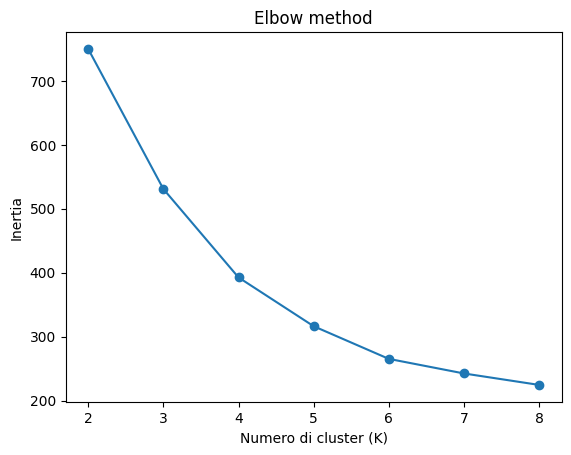

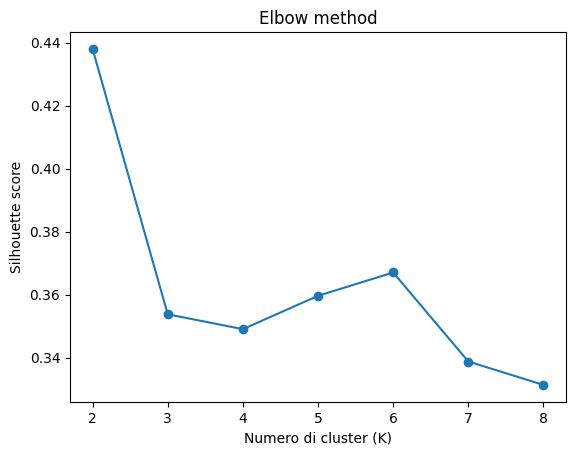

In [26]:
# Scaling
features = ['mean_temp', 'std_temp', 'rain_total', 'days_rain', 'snow_total', 'days_snow', 'mean_daylight', 'mean_sunshine']
X = df_clusters_third[features].copy()

#Log transform per asimmetria - consigliato ma da capire
#X["rain_total"] = np.log1p(X["rain_total"])
#X["snow_total"] = np.log1p(X["snow_total"])

#X.head(5)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

sil_scores = []
inertia = []

K_range = range(2, 9)

for k in range(2, 9):
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = km.fit_predict(X_scaled)
    sil_scores.append(silhouette_score(X_scaled, labels))
    inertia.append(km.inertia_)

print(f"Silhouette scores: {sil_scores}")
print(f"Inertia scores: {inertia}")


plot_inertia(inertia, K_range)
plot_silhouette(sil_scores, K_range)

In [27]:
# Top cluster
k = 5
kmeans = KMeans(n_clusters=k, random_state=42, n_init=20)

df_clusters_third["cluster"] = kmeans.fit_predict(X_scaled)

C:\Users\gabri\AppData\Local\Temp\ipykernel_4608\3029263333.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clusters_third["cluster"] = kmeans.fit_predict(X_scaled)


In [28]:
centroids_scaled = kmeans.cluster_centers_
centroids = scaler.inverse_transform(centroids_scaled)

cluster_summary = (
    pd.DataFrame(centroids, columns=features)
    .assign(cluster=range(k))
)

cluster_summary

,mean_temp,std_temp,rain_total,days_rain,snow_total,days_snow,mean_daylight,mean_sunshine,cluster
0,24.486776,1.684082,13206.579630,1721.018519,6.889815,2.000000,43647.071315,35818.379331,0
1,7.082462,8.258578,7441.413333,1123.200000,1535.072000,374.466667,44393.989360,25967.233730,1
2,21.868173,5.467822,4600.661905,570.547619,9.498333,2.571429,43752.043995,36756.931756,2
3,11.905223,8.400454,7281.883871,1018.612903,379.013871,91.774194,44041.993476,30235.095984,3
4,24.525610,1.314008,29996.790476,2594.761905,21.650000,5.761905,43642.528272,32697.765474,4


C:\Users\gabri\AppData\Local\Temp\ipykernel_4608\991988466.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clusters_third['country'] = df_clusters_third['capital'].map(capital_to_country)


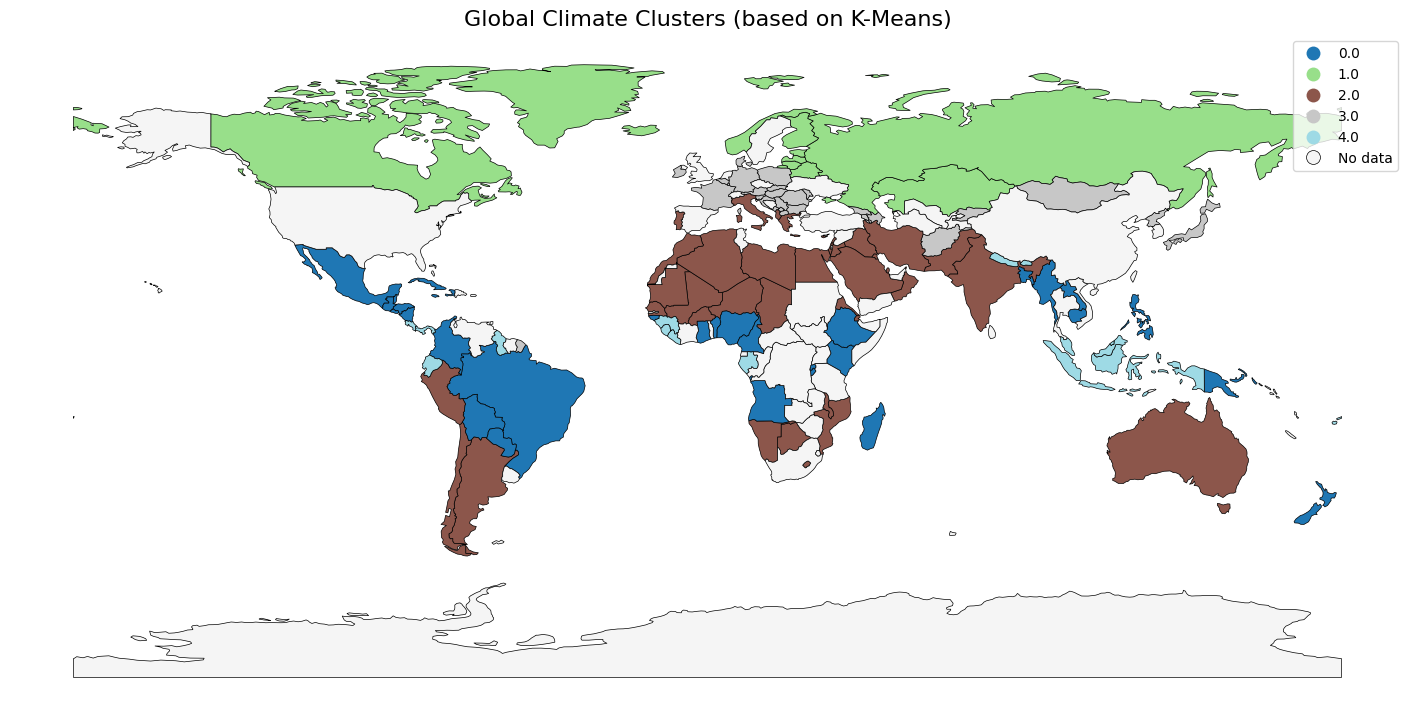

In [29]:
df_clusters_third['country'] = df_clusters_third['capital'].map(capital_to_country)
df_clusters_third.head(5)
plot_world(df_clusters_third, "K-Means")

Third decade

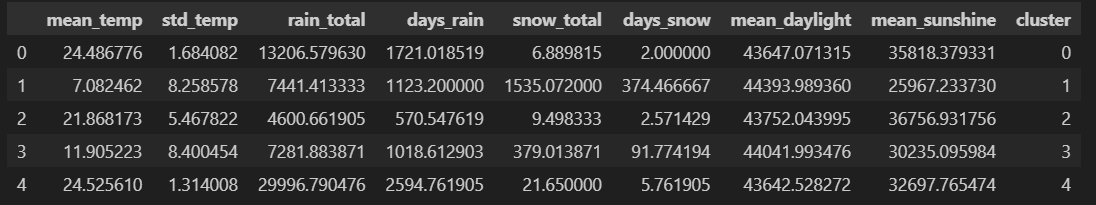

Second decade

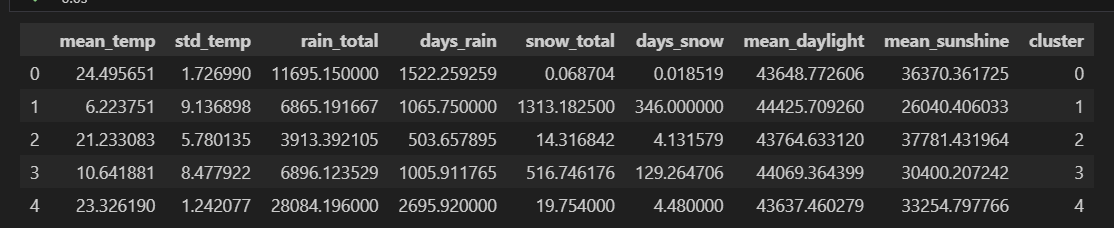

First decade

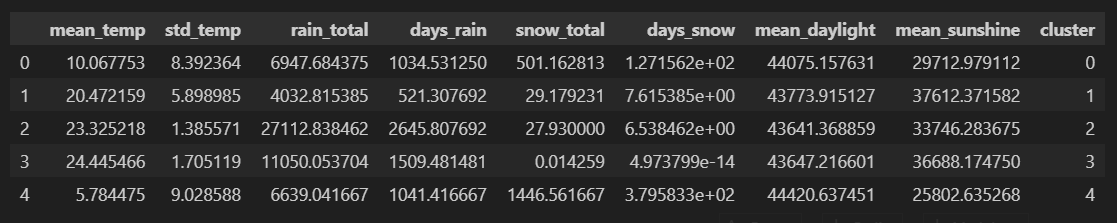

# Clustering per gruppo

In [40]:
df_clusters_g1 = aggregation_per_capital_group[aggregation_per_capital_group["group"] == 1]
print(df_clusters_g1.head(5))

df_clusters_g2 = aggregation_per_capital_group[aggregation_per_capital_group["group"] == 2]
print(df_clusters_g2.head(5))

       capital  group  mean_temp  std_temp  rain_total  days_rain  snow_total  \
0        Abuja      1  26.820369  2.218075     20979.7       2395        0.00   
2        Accra      1  26.785454  1.493535      8672.0       1651        0.00   
4  Addis Ababa      1  15.783793  1.400809     27083.8       2434        0.00   
6      Algiers      1  18.224740  5.857749      8476.2       1169        3.01   
8        Alofi      1  25.156999  1.351654     27549.5       2573        0.00   

   days_snow  mean_daylight  mean_sunshine  
0          0   43653.233453   33628.210345  
2          0   43638.100350   36360.994713  
4          0   43653.233453   37901.598648  
6          2   43879.002510   37448.616525  
8          0   43578.519310   35540.443329  
       capital  group  mean_temp  std_temp  rain_total  days_rain  snow_total  \
1        Abuja      2  26.826519  2.183452     17597.2       2156        0.00   
3        Accra      2  26.911216  1.424467     11560.3       2190        0.00   


## 1995-2009

Silhouette scores: [np.float64(0.4646098005270761), np.float64(0.356386476276491), np.float64(0.3521829688860021), np.float64(0.35869306506168974), np.float64(0.34837191372534865), np.float64(0.3500051428616421), np.float64(0.27814281204567837)]
Inertia scores: [705.4713844691007, 497.55446807600725, 388.228201678384, 307.0812956157781, 272.35606423406244, 240.38973668487927, 221.3320147542303]


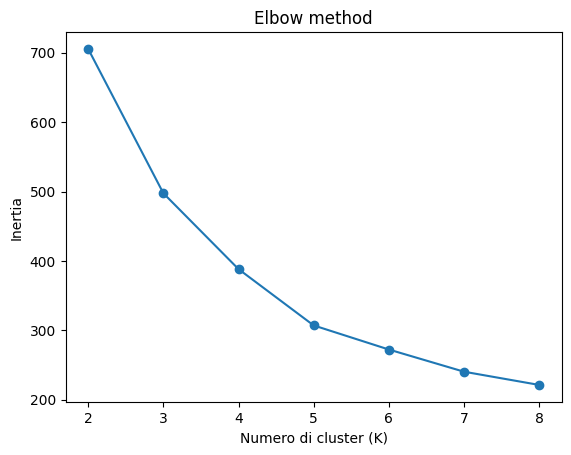

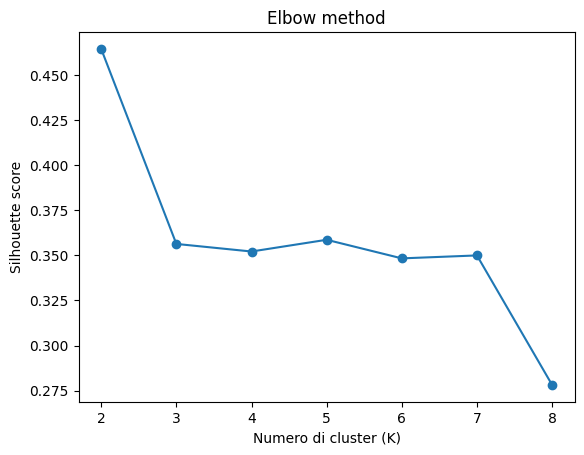

In [41]:
# Scaling
features = ['mean_temp', 'std_temp', 'rain_total', 'days_rain', 'snow_total', 'days_snow', 'mean_daylight', 'mean_sunshine']
X = df_clusters_g1[features].copy()

#Log transform per asimmetria - consigliato ma da capire
#X["rain_total"] = np.log1p(X["rain_total"])
#X["snow_total"] = np.log1p(X["snow_total"])

#X.head(5)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

sil_scores = []
inertia = []

K_range = range(2, 9)

for k in range(2, 9):
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = km.fit_predict(X_scaled)
    sil_scores.append(silhouette_score(X_scaled, labels))
    inertia.append(km.inertia_)

print(f"Silhouette scores: {sil_scores}")
print(f"Inertia scores: {inertia}")


plot_inertia(inertia, K_range)
plot_silhouette(sil_scores, K_range)

In [42]:
# Top cluster
k = 5
kmeans = KMeans(n_clusters=k, random_state=42, n_init=20)

df_clusters_g1["cluster"] = kmeans.fit_predict(X_scaled)

C:\Users\gabri\AppData\Local\Temp\ipykernel_4608\1499316690.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clusters_g1["cluster"] = kmeans.fit_predict(X_scaled)


In [43]:
centroids_scaled = kmeans.cluster_centers_
centroids = scaler.inverse_transform(centroids_scaled)

cluster_summary = (
    pd.DataFrame(centroids, columns=features)
    .assign(cluster=range(k))
)

cluster_summary

,mean_temp,std_temp,rain_total,days_rain,snow_total,days_snow,mean_daylight,mean_sunshine,cluster
0,6.029523,8.540717,10224.400000,1640.769231,2021.384615,5.256923e+02,44447.064710,25605.747293,0
1,24.488625,1.749379,17041.810909,2268.527273,0.020364,-7.105427e-14,43649.031157,36545.397310,1
2,20.716725,5.814129,5988.281579,778.315789,28.298421,8.473684e+00,43772.341858,37653.305057,2
3,23.269126,1.272057,41194.848000,4022.720000,40.098800,9.280000e+00,43637.355985,33708.679942,3
4,10.382779,8.609243,10160.893750,1489.562500,745.679375,1.890000e+02,44048.465326,30356.559819,4


C:\Users\gabri\AppData\Local\Temp\ipykernel_4608\1154834811.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clusters_g1['country'] = df_clusters_g1['capital'].map(capital_to_country)


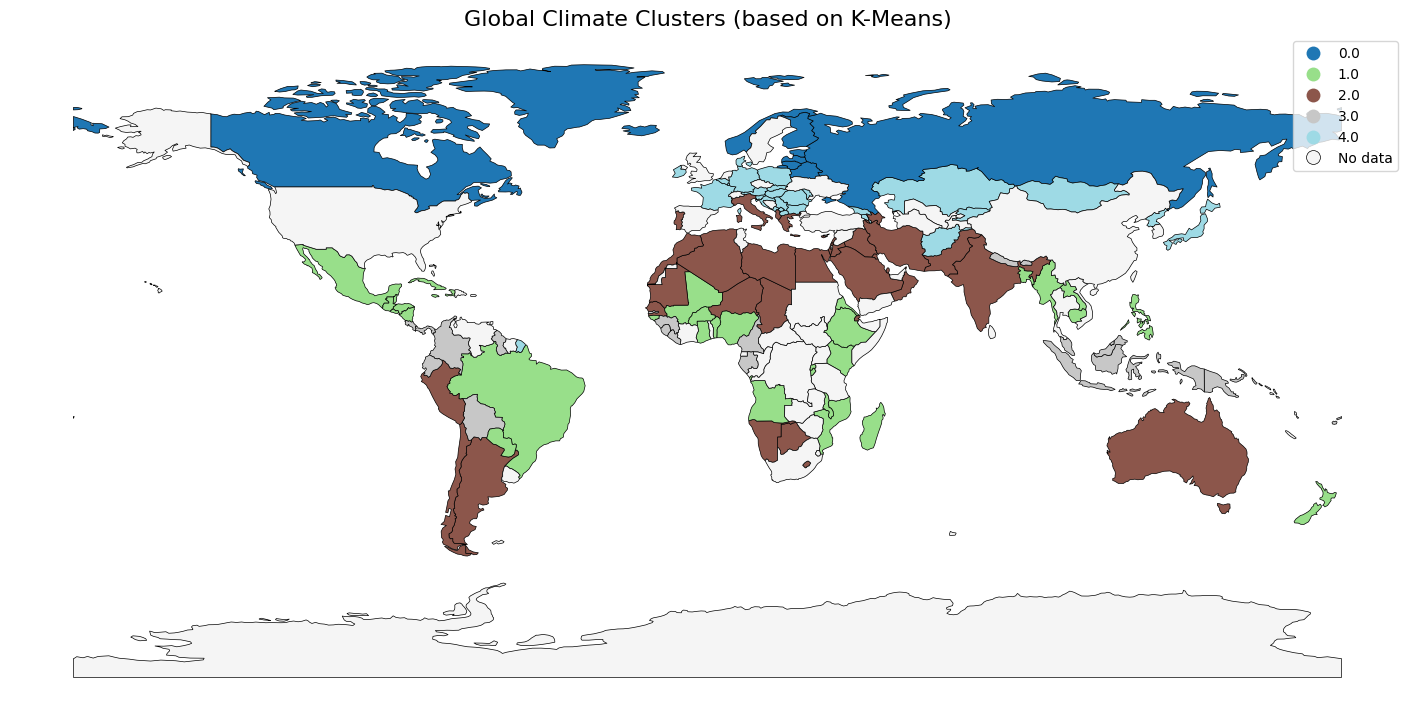

In [44]:
df_clusters_g1['country'] = df_clusters_g1['capital'].map(capital_to_country)
df_clusters_g1.head(5)
plot_world(df_clusters_g1, "K-Means")

## 2010-2024

Silhouette scores: [np.float64(0.4537173206284833), np.float64(0.3604209429058513), np.float64(0.368903456279201), np.float64(0.3734475632126528), np.float64(0.3782406017574225), np.float64(0.35835004621068034), np.float64(0.3251270417113097)]
Inertia scores: [721.4964845935414, 504.17468651656844, 384.10821159343175, 302.53810562658555, 259.8164975346484, 233.47615261671376, 214.44604414263983]


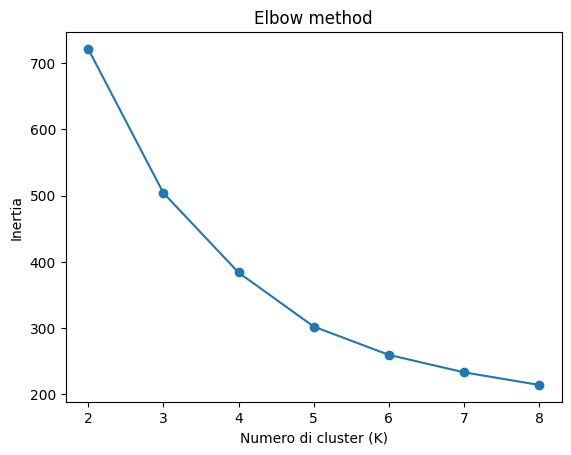

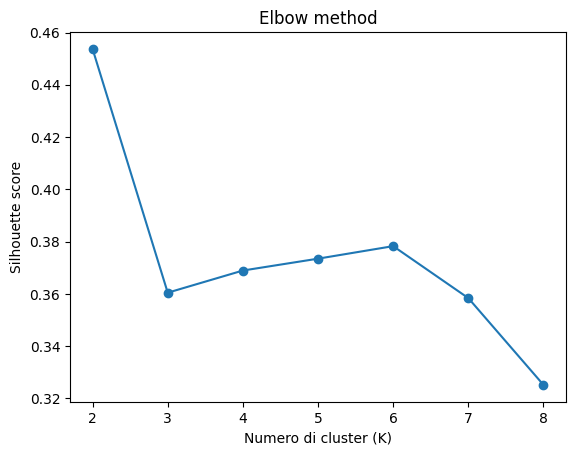

In [45]:
# Scaling
features = ['mean_temp', 'std_temp', 'rain_total', 'days_rain', 'snow_total', 'days_snow', 'mean_daylight', 'mean_sunshine']
X = df_clusters_g2[features].copy()

#Log transform per asimmetria - consigliato ma da capire
#X["rain_total"] = np.log1p(X["rain_total"])
#X["snow_total"] = np.log1p(X["snow_total"])

#X.head(5)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

sil_scores = []
inertia = []

K_range = range(2, 9)

for k in range(2, 9):
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = km.fit_predict(X_scaled)
    sil_scores.append(silhouette_score(X_scaled, labels))
    inertia.append(km.inertia_)

print(f"Silhouette scores: {sil_scores}")
print(f"Inertia scores: {inertia}")


plot_inertia(inertia, K_range)
plot_silhouette(sil_scores, K_range)

In [46]:
# Top cluster
k = 5
kmeans = KMeans(n_clusters=k, random_state=42, n_init=20)

df_clusters_g2["cluster"] = kmeans.fit_predict(X_scaled)

C:\Users\gabri\AppData\Local\Temp\ipykernel_4608\1289315659.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clusters_g2["cluster"] = kmeans.fit_predict(X_scaled)


In [47]:
centroids_scaled = kmeans.cluster_centers_
centroids = scaler.inverse_transform(centroids_scaled)

cluster_summary = (
    pd.DataFrame(centroids, columns=features)
    .assign(cluster=range(k))
)

cluster_summary

,mean_temp,std_temp,rain_total,days_rain,snow_total,days_snow,mean_daylight,mean_sunshine,cluster
0,24.278999,1.686726,19415.792727,2523.072727,7.948182,2.218182,43647.850776,35927.605381,0
1,6.844281,8.603902,10758.046667,1659.933333,2098.343333,527.666667,44395.747092,26212.622465,1
2,11.593236,8.512353,10700.138710,1506.903226,649.952258,157.419355,44043.152267,30245.452868,2
3,21.818178,5.539638,6799.148780,833.463415,18.078780,4.780488,43754.013543,37046.663125,3
4,24.420945,1.314568,44823.266667,3967.380952,29.070000,7.523810,43642.613579,32830.010166,4


C:\Users\gabri\AppData\Local\Temp\ipykernel_4608\3000508759.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clusters_g2['country'] = df_clusters_g2['capital'].map(capital_to_country)


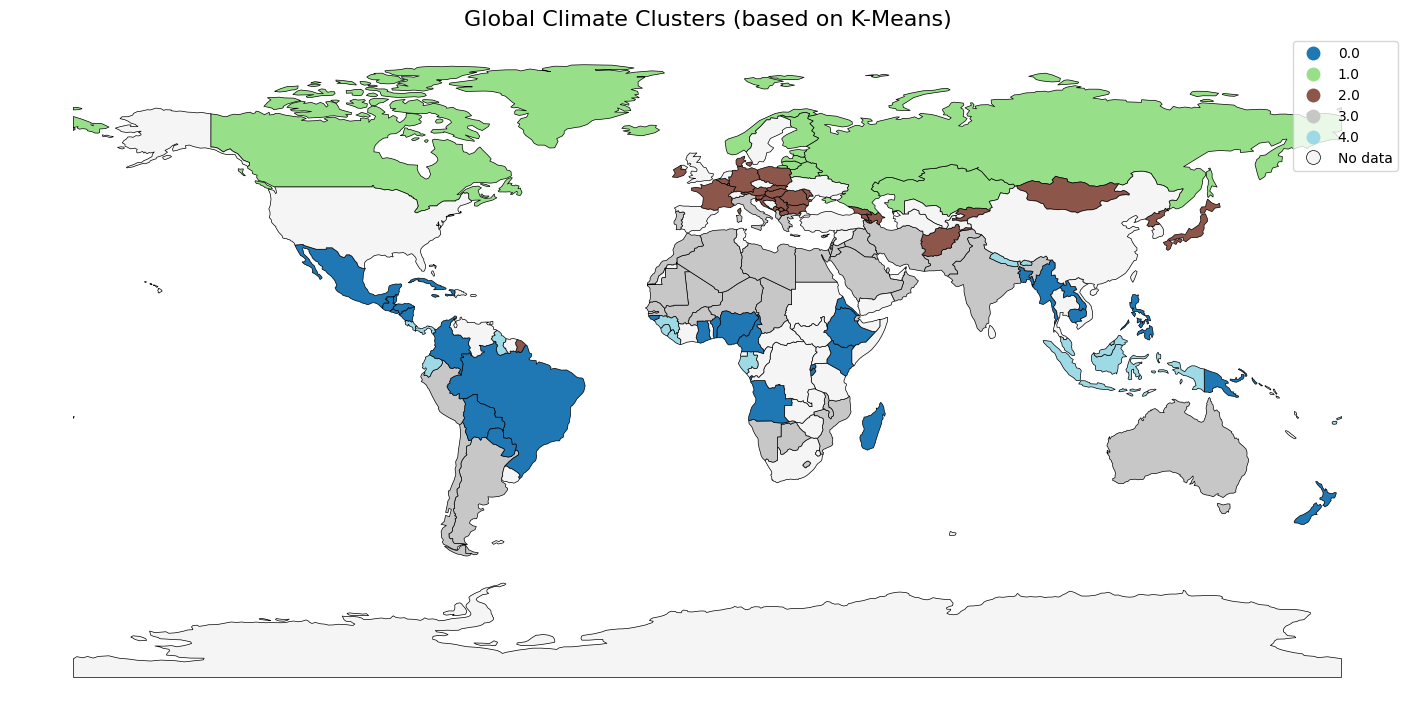

In [48]:
df_clusters_g2['country'] = df_clusters_g2['capital'].map(capital_to_country)
df_clusters_g2.head(5)
plot_world(df_clusters_g2, "K-Means")

First
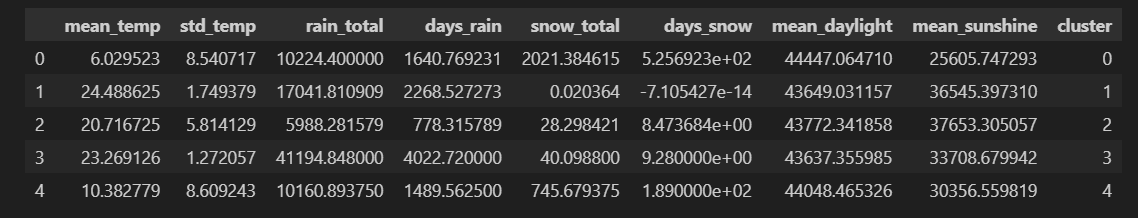

Second
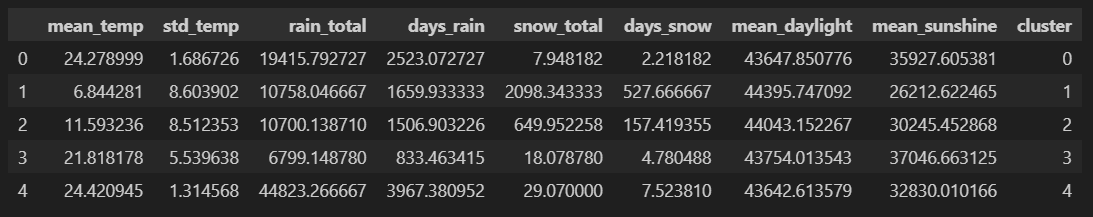